# Evolution of Intent Classification: From BERT Flat → Hierarchical → SBERT Ensemble
### Banking77-Modified Dataset (78 classes)

This notebook proves a clear performance evolution across **4 model stages**:

| Stage | Model | Key Idea |
|-------|-------|----------|
| **Stage 1** | BERT Flat | Vanilla BERT, single head, 78-way classification |
| **Stage 2** | BERT Hierarchical | Dual-head: coarse routing + fine prediction |
| **Stage 3** | BERT Hier + SBERT-A | Strategy A: Confidence-gap routing to SBERT |
| **Stage 4** | BERT Hier + SBERT-B | Strategy B: Weighted score fusion |

**Expected result:** Each stage is provably stronger than the previous.



## 1. Install & Imports

In [19]:
!pip install -q transformers datasets evaluate scikit-learn accelerate tqdm sentence-transformers huggingface_hub

import os, json, random, warnings, shutil, zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 2. Hyperparameters & Paths

In [20]:
TRAIN_PATH = '/kaggle/working/train_final_augmented.csv'
TEST_PATH  = '/kaggle/working/test_final_clean.csv'
OUTPUT_DIR = '/kaggle/working/bert_sbert_ensemble'
PLOTS_DIR  = f'{OUTPUT_DIR}/plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

MODEL_NAME      = 'bert-base-uncased'
MAX_LEN         = 128
GRAD_ACCUM      = 4
EPOCHS          = 10
LR              = 3e-5
WARMUP_RATIO    = 0.1
PATIENCE        = 3
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.1
COARSE_WEIGHT   = 0.5   # FIX: was 0.3 — coarse head needs equal weight so routing is reliable
FINE_WEIGHT     = 0.5   # FIX: was 0.7
VAL_SIZE        = 0.15  # FIX: was 0.10 — more val samples per class for stable early stopping
DROPOUT         = 0.2

if DEVICE.type == 'cuda':
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    BATCH_SIZE = 32 if vram_gb >= 10 else 16
    print(f'VRAM: {vram_gb:.1f} GB  →  BATCH_SIZE = {BATCH_SIZE}')
else:
    BATCH_SIZE = 16
    print('CPU mode — BATCH_SIZE = 16')

SBERT_MODEL_NAME = 'all-mpnet-base-v2'
SBERT_TOP_K      = 5
CONF_THRESHOLD   = None   # tuned on val set in Section 15
FUSION_ALPHA     = None   # tuned on val set in Section 16

print(f'Model          : {MODEL_NAME}')
print(f'Effective batch: {BATCH_SIZE * GRAD_ACCUM}')
print(f'SBERT model    : {SBERT_MODEL_NAME}')
print(f'Coarse/Fine weights: {COARSE_WEIGHT}/{FINE_WEIGHT}')


VRAM: 15.6 GB  →  BATCH_SIZE = 32
Model          : bert-base-uncased
Effective batch: 128
SBERT model    : all-mpnet-base-v2
Coarse/Fine weights: 0.5/0.5


## 3. Data Loading, Coarse Mapping & Train/Val Split

In [21]:
train_raw = pd.read_csv(TRAIN_PATH)
test_df   = pd.read_csv(TEST_PATH)
print('Train shape:', train_raw.shape, '  Test shape:', test_df.shape)
print('Columns:', train_raw.columns.tolist())
print(train_raw.head(3))

coarse_mapping = {
    'neutral': 'neutral',
    'card_arrival': 'card_delivery', 'card_delivery_estimate': 'card_delivery',
    'order_physical_card': 'card_delivery', 'get_physical_card': 'card_delivery',
    'getting_spare_card': 'card_delivery', 'card_about_to_expire': 'card_delivery',
    'activate_my_card': 'card_functionality', 'card_linking': 'card_functionality',
    'card_not_working': 'card_functionality', 'card_swallowed': 'card_functionality',
    'contactless_not_working': 'card_functionality', 'pin_blocked': 'card_functionality',
    'change_pin': 'card_functionality', 'card_acceptance': 'card_functionality',
    'visa_or_mastercard': 'card_functionality', 'disposable_card_limits': 'card_functionality',
    'getting_virtual_card': 'virtual_card', 'get_disposable_virtual_card': 'virtual_card',
    'virtual_card_not_working': 'virtual_card', 'apple_pay_or_google_pay': 'virtual_card',
    'lost_or_stolen_card': 'security_and_fraud', 'lost_or_stolen_phone': 'security_and_fraud',
    'compromised_card': 'security_and_fraud', 'passcode_forgotten': 'security_and_fraud',
    'verify_my_identity': 'security_and_fraud', 'verify_source_of_funds': 'security_and_fraud',
    'verify_top_up': 'security_and_fraud', 'why_verify_identity': 'security_and_fraud',
    'unable_to_verify_identity': 'security_and_fraud', 'card_payment_not_recognised': 'security_and_fraud',
    'card_payment_fee_charged': 'fees_and_charges', 'card_payment_wrong_exchange_rate': 'fees_and_charges',
    'cash_withdrawal_charge': 'fees_and_charges', 'exchange_charge': 'fees_and_charges',
    'extra_charge_on_statement': 'fees_and_charges', 'top_up_by_bank_transfer_charge': 'fees_and_charges',
    'top_up_by_card_charge': 'fees_and_charges', 'transfer_fee_charged': 'fees_and_charges',
    'topping_up_by_card': 'top_up_and_funding', 'top_up_by_cash_or_cheque': 'top_up_and_funding',
    'top_up_failed': 'top_up_and_funding', 'top_up_limits': 'top_up_and_funding',
    'top_up_reverted': 'top_up_and_funding', 'pending_top_up': 'top_up_and_funding',
    'automatic_top_up': 'top_up_and_funding',
    'transfer_into_account': 'transfers_and_payments', 'receiving_money': 'transfers_and_payments',
    'cancel_transfer': 'transfers_and_payments', 'declined_transfer': 'transfers_and_payments',
    'failed_transfer': 'transfers_and_payments', 'pending_transfer': 'transfers_and_payments',
    'transfer_not_received_by_recipient': 'transfers_and_payments', 'transfer_timing': 'transfers_and_payments',
    'beneficiary_not_allowed': 'transfers_and_payments', 'declined_card_payment': 'transfers_and_payments',
    'pending_card_payment': 'transfers_and_payments', 'reverted_card_payment': 'transfers_and_payments',
    'direct_debit_payment_not_recognised': 'transfers_and_payments', 'transaction_charged_twice': 'transfers_and_payments',
    'balance_not_updated_after_bank_transfer': 'account_and_balance',
    'balance_not_updated_after_cheque_or_cash_deposit': 'account_and_balance',
    'refund_not_showing_up': 'account_and_balance', 'request_refund': 'account_and_balance',
    'cash_withdrawal_not_recognised': 'account_and_balance', 'wrong_amount_of_cash_received': 'account_and_balance',
    'declined_cash_withdrawal': 'account_and_balance', 'pending_cash_withdrawal': 'account_and_balance',
    'atm_support': 'account_and_balance',
    'age_limit': 'general_account_management', 'country_support': 'general_account_management',
    'edit_personal_details': 'general_account_management', 'terminate_account': 'general_account_management',
    'fiat_currency_support': 'general_account_management', 'supported_cards_and_currencies': 'general_account_management',
    'exchange_rate': 'general_account_management', 'exchange_via_app': 'general_account_management',
    'wrong_exchange_rate_for_cash_withdrawal': 'general_account_management',
}

def apply_coarse(df):
    df = df.copy()
    df['category'] = df['category'].str.lower().str.strip()
    df['category'] = df['category'].replace({'reverted_card_payment?': 'reverted_card_payment'})
    df['coarse_category'] = df['category'].map(coarse_mapping)
    missing = df['coarse_category'].isna().sum()
    if missing:
        print(f'WARNING: {missing} unmapped rows:', df[df['coarse_category'].isna()]['category'].unique())
    return df.dropna(subset=['coarse_category']).reset_index(drop=True)

train_raw = apply_coarse(train_raw)
test_df   = apply_coarse(test_df)

train_df, val_df = train_test_split(
    train_raw, test_size=VAL_SIZE, random_state=SEED, stratify=train_raw['category']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')
print(f'Fine classes: {train_df["category"].nunique()}  Coarse: {train_df["coarse_category"].nunique()}')


Train shape: (10957, 4)   Test shape: (3115, 5)
Columns: ['text', 'category', 'char_length', 'word_count']
                                            text            category  \
0           Where do I go to verify my identity?  verify_my_identity   
1                    My new card hasn't came in.        card_arrival   
2  Can I possibly change my currency to another?    exchange_via_app   

   char_length  word_count  
0         36.0         8.0  
1         27.0         6.0  
2         45.0         8.0  
Train: 9,313  Val: 1,644  Test: 3,115
Fine classes: 78  Coarse: 10


## 4. Label Encoding & Class Weights

In [22]:
fine_le = LabelEncoder()
train_df['fine_label'] = fine_le.fit_transform(train_df['category'])
val_df['fine_label']   = fine_le.transform(val_df['category'])
test_df['fine_label']  = fine_le.transform(test_df['category'])
NUM_FINE = len(fine_le.classes_)

coarse_le = LabelEncoder()
train_df['coarse_label'] = coarse_le.fit_transform(train_df['coarse_category'])
val_df['coarse_label']   = coarse_le.transform(val_df['coarse_category'])
test_df['coarse_label']  = coarse_le.transform(test_df['coarse_category'])
NUM_COARSE = len(coarse_le.classes_)

# Coarse → valid fine IDs map (hierarchical logit masking)
coarse_to_fine_ids = {i: [] for i in range(NUM_COARSE)}
for _, row in train_df.iterrows():
    coarse_to_fine_ids[row['coarse_label']].append(row['fine_label'])
coarse_to_fine_ids = {k: list(set(v)) for k, v in coarse_to_fine_ids.items()}

fine_weights   = compute_class_weight('balanced', classes=np.arange(NUM_FINE),   y=train_df['fine_label'].values)
coarse_weights = compute_class_weight('balanced', classes=np.arange(NUM_COARSE), y=train_df['coarse_label'].values)
fine_weights_t   = torch.tensor(fine_weights,   dtype=torch.float).to(DEVICE)
coarse_weights_t = torch.tensor(coarse_weights, dtype=torch.float).to(DEVICE)

id2fine   = {int(i): str(c) for i, c in enumerate(fine_le.classes_)}
id2coarse = {int(i): str(c) for i, c in enumerate(coarse_le.classes_)}

# Save mappings
with open(f'{OUTPUT_DIR}/id2fine.json',   'w') as f: json.dump(id2fine,   f, indent=2)
with open(f'{OUTPUT_DIR}/id2coarse.json', 'w') as f: json.dump(id2coarse, f, indent=2)
with open(f'{OUTPUT_DIR}/coarse_to_fine_ids.json', 'w') as f:
    json.dump({str(k): v for k, v in coarse_to_fine_ids.items()}, f, indent=2)
with open(f'{OUTPUT_DIR}/coarse_mapping.json', 'w') as f: json.dump(coarse_mapping, f, indent=2)

print(f'Fine classes: {NUM_FINE}  Coarse classes: {NUM_COARSE}')
print(f'Fine weights — min: {fine_weights.min():.4f}  max: {fine_weights.max():.4f}')
print('Mappings saved.')


Fine classes: 78  Coarse classes: 10
Fine weights — min: 0.4472  max: 1.1940
Mappings saved.


## 5. Tokenizer, Datasets & DataLoaders

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HierarchicalDataset(Dataset):
    def __init__(self, texts, fine_labels, coarse_labels, tokenizer, max_len):
        self.texts, self.fine_labels, self.coarse_labels = texts, fine_labels, coarse_labels
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), max_length=self.max_len,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids'    : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'fine_label'   : torch.tensor(self.fine_labels[idx],   dtype=torch.long),
            'coarse_label' : torch.tensor(self.coarse_labels[idx], dtype=torch.long),
        }

train_ds = HierarchicalDataset(train_df['text'].values, train_df['fine_label'].values,
                                train_df['coarse_label'].values, tokenizer, MAX_LEN)
val_ds   = HierarchicalDataset(val_df['text'].values,   val_df['fine_label'].values,
                                val_df['coarse_label'].values,   tokenizer, MAX_LEN)
test_ds  = HierarchicalDataset(test_df['text'].values,  test_df['fine_label'].values,
                                test_df['coarse_label'].values,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')


Train batches: 292  Val: 52  Test: 98


## 6. Shared Utilities — Loss, Optimizer Builder, Evaluate Functions

In [24]:
# ── Label Smoothing Cross Entropy ─────────────────────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight
    def forward(self, logits, targets):
        n = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth = torch.full_like(log_p, self.smoothing / (n - 1))
            smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        loss = -(smooth * log_p).sum(dim=-1)
        if self.weight is not None:
            w = self.weight[targets]
            return (loss * w).sum() / w.sum()
        return loss.mean()

# ── Layer-wise LR decay optimizer builder ─────────────────────────────────────
def build_optimizer(model_ref, lr, weight_decay, n_encoder_layers):
    encoder_layers = model_ref.encoder.encoder.layer
    param_groups = [{'params': model_ref.encoder.embeddings.parameters(), 'lr': lr * 0.05}]
    for i, layer in enumerate(encoder_layers):
        factor = 0.1 + 0.7 * (i / max(n_encoder_layers - 1, 1))
        param_groups.append({'params': layer.parameters(), 'lr': lr * factor})
    # Add classification heads
    for name, param in model_ref.named_parameters():
        if 'encoder' not in name:
            param_groups.append({'params': [param], 'lr': lr})
    return AdamW(param_groups, weight_decay=weight_decay)

# ── Flat evaluate (Stage 1) ────────────────────────────────────────────────────
def evaluate_flat(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            fl   = batch['fine_label'].to(device)
            logits = model(ids, mask)
            total_loss += criterion(logits, fl).item()
            all_preds.extend(logits.argmax(-1).cpu().numpy())
            all_labels.extend(fl.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    mf1  = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    wf1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, mf1, wf1, all_preds, all_labels

# ── Hierarchical evaluate (Stages 2-4) ────────────────────────────────────────
def evaluate_hier(model, loader, fine_crit, coarse_crit, device, c2f):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    all_coarse_preds, all_coarse_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            fl   = batch['fine_label'].to(device)
            cl   = batch['coarse_label'].to(device)
            cl_logits, fl_logits = model(ids, mask)
            loss = COARSE_WEIGHT * coarse_crit(cl_logits, cl) + FINE_WEIGHT * fine_crit(fl_logits, fl)
            total_loss += loss.item()
            cp = cl_logits.argmax(-1).cpu().numpy()
            masked = fl_logits.clone()
            for i, c in enumerate(cp):
                mv = torch.full((fl_logits.size(1),), float('-inf'), device=device)
                mv[c2f[int(c)]] = 0.0
                masked[i] += mv
            all_preds.extend(masked.argmax(-1).cpu().numpy())
            all_labels.extend(fl.cpu().numpy())
            all_coarse_preds.extend(cp)
            all_coarse_labels.extend(cl.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    mf1  = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    wf1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cacc = accuracy_score(all_coarse_labels, all_coarse_preds)
    return avg_loss, acc, mf1, wf1, cacc, all_preds, all_labels, all_coarse_preds, all_coarse_labels

# ── Generic training loop ──────────────────────────────────────────────────────
def run_training_loop(model, train_loader, val_loader, optimizer, scheduler,
                       epochs, patience, grad_accum, device,
                       eval_fn, eval_kwargs, save_path, label):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_mf1': [], 'val_wf1': []}
    best_val_loss, pat_count, epochs_ran = float('inf'), 0, 0
    print(f'\n{'='*75}')
    print(f'  Training: {label}')
    print(f'{'='*75}')
    print(f'{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>8}  {"Val Acc":>8}  {"Macro F1":>8}  {"WtF1":>6}')
    print('-'*75)
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()
        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f'Epoch {epoch}/{epochs}', leave=False)
        for step, batch in pbar:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            fl   = batch['fine_label'].to(device)
            cl   = batch['coarse_label'].to(device)
            loss = eval_kwargs['loss_fn'](model, ids, mask, fl, cl)
            (loss / grad_accum).backward()
            train_loss += loss.item()
            if (step + 1) % grad_accum == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        if len(train_loader) % grad_accum != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        avg_train = train_loss / len(train_loader)
        val_out   = eval_kwargs['eval_fn'](model, val_loader)
        val_loss, val_acc, val_mf1, val_wf1 = val_out[0], val_out[1], val_out[2], val_out[3]
        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_mf1'].append(val_mf1)
        history['val_wf1'].append(val_wf1)
        epochs_ran = epoch
        marker = ''
        if val_loss < best_val_loss:
            best_val_loss = val_loss; pat_count = 0
            m_save = model.module if hasattr(model, 'module') else model
            torch.save(m_save.state_dict(), save_path)
            marker = '  ✓ best'
        else:
            pat_count += 1
            marker = f'  patience {pat_count}/{patience}'
        print(f'{epoch:>5}  {avg_train:>10.4f}  {val_loss:>8.4f}  '
              f'{val_acc*100:>7.2f}%  {val_mf1:>8.4f}  {val_wf1:>6.4f}{marker}')
        if pat_count >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break
    print(f'Best val loss: {best_val_loss:.4f}')
    history['epochs_ran'] = epochs_ran
    return history


---
# STAGE 1 — BERT Flat (Baseline)

Vanilla BERT with a **single classification head** directly over 78 fine-grained classes.
No hierarchy, no coarse routing — the simplest possible approach.

```
bert-base-uncased
      ↓ [CLS] 768-dim
 Dropout → Linear(768 → 78)
      ↓
  78-way softmax
```

## 7. Stage 1 Model — Flat BERT

In [25]:
class FlatBERT(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.2):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, num_classes))
    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]   # [CLS]
        return self.head(pooled)

flat_model = FlatBERT(MODEL_NAME, NUM_FINE, DROPOUT).to(DEVICE)
if torch.cuda.device_count() > 1:
    flat_model = nn.DataParallel(flat_model)

total = sum(p.numel() for p in flat_model.parameters())
print(f'Stage 1 — FlatBERT  |  Params: {total:,}  |  Output: {NUM_FINE} classes')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stage 1 — FlatBERT  |  Params: 109,542,222  |  Output: 78 classes


## 8. Stage 1 — Train Flat BERT

In [26]:
flat_criterion = LabelSmoothingCE(LABEL_SMOOTHING, weight=fine_weights_t)

flat_ref = flat_model.module if hasattr(flat_model, 'module') else flat_model
flat_opt = build_optimizer(flat_ref, LR, WEIGHT_DECAY,
                            len(flat_ref.encoder.encoder.layer))

total_steps_flat  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
flat_scheduler    = get_cosine_schedule_with_warmup(
    flat_opt, int(WARMUP_RATIO * total_steps_flat), total_steps_flat)

def flat_loss_fn(model, ids, mask, fl, cl):
    return flat_criterion(model(ids, mask), fl)

def flat_eval_fn(model, loader):
    return evaluate_flat(model, loader, flat_criterion, DEVICE)

history_flat = run_training_loop(
    flat_model, train_loader, val_loader,
    flat_opt, flat_scheduler,
    EPOCHS, PATIENCE, GRAD_ACCUM, DEVICE,
    eval_fn=None,
    eval_kwargs={'loss_fn': flat_loss_fn, 'eval_fn': flat_eval_fn},
    save_path=f'{OUTPUT_DIR}/best_flat.pt',
    label='Stage 1 — Flat BERT'
)
with open(f'{OUTPUT_DIR}/history_flat.json', 'w') as f: json.dump(history_flat, f)



  Training: Stage 1 — Flat BERT
Epoch  Train Loss  Val Loss   Val Acc  Macro F1    WtF1
---------------------------------------------------------------------------


Epoch 1/10:   0%|          | 0/292 [00:00<?, ?it/s]

    1      4.2959    3.8202    27.74%    0.2357  0.2411  ✓ best


Epoch 2/10:   0%|          | 0/292 [00:00<?, ?it/s]

    2      3.0999    2.1207    71.96%    0.7030  0.7045  ✓ best


...

    8      1.0149    1.0961    90.39%    0.9042  0.9045  ✓ best


Epoch 9/10:   0%|          | 0/292 [00:00<?, ?it/s]

    9      1.0019    1.0936    90.39%    0.9038  0.9045  ✓ best


Epoch 10/10:   0%|          | 0/292 [00:00<?, ?it/s]

   10      0.9932    1.0932    90.33%    0.9032  0.9039  ✓ best
Best val loss: 1.0932


## 9. Stage 1 — Test Evaluation

In [27]:
flat_ref = flat_model.module if hasattr(flat_model, 'module') else flat_model
flat_ref.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_flat.pt'))
flat_ref.eval()

_, s1_acc, s1_mf1, s1_wf1, s1_preds, s1_labels = evaluate_flat(
    flat_ref, test_loader, flat_criterion, DEVICE)

print(f'Stage 1 — BERT Flat   |  Accuracy: {s1_acc*100:.2f}%  '
      f'Macro F1: {s1_mf1:.4f}  Weighted F1: {s1_wf1:.4f}')

report_flat = classification_report(
    s1_labels, s1_preds, target_names=fine_le.classes_, digits=3)
with open(f'{OUTPUT_DIR}/report_stage1_flat.txt', 'w') as f: f.write(report_flat)
print('Classification report saved.')


Stage 1 — BERT Flat   |  Accuracy: 91.20%  Macro F1: 0.9115  Weighted F1: 0.9122
Classification report saved.


---
# STAGE 2 — BERT Hierarchical (Dual-Head)

Adds a **coarse head** (9 categories) whose soft probabilities feed into the fine head.
At inference, logit masking constrains fine predictions to only classes belonging to the predicted coarse group.

```
bert-base-uncased
      ↓ [CLS] 768-dim
  ┌───┴────────────┐
  Coarse Head (9)  Fine Head (768 + 9 → 78)
  ↓ soft probs ────►  concatenated input
  Coarse loss      Fine loss (with logit masking at inference)
  L = 0.3·L_coarse + 0.7·L_fine
```

## 10. Stage 2 Model — Dual-Head BERT

In [28]:
class DualHeadBERT(nn.Module):
    def __init__(self, model_name, num_fine, num_coarse, dropout=0.2):
        super().__init__()
        # FIX: Two separate encoders so fine-head gradients cannot drown the coarse head
        self.coarse_encoder = AutoModel.from_pretrained(model_name)
        self.fine_encoder   = AutoModel.from_pretrained(model_name)
        hidden = self.fine_encoder.config.hidden_size

        self.coarse_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_coarse)
        )
        self.fine_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden + num_coarse, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_fine)
        )

    def forward(self, input_ids, attention_mask):
        # Coarse encoder: dedicated representation for routing
        coarse_pooled = self.coarse_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        coarse_logits = self.coarse_head(coarse_pooled)
        coarse_probs  = F.softmax(coarse_logits, dim=-1)

        # Fine encoder: conditioned on the coarse routing signal
        fine_pooled = self.fine_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        ).last_hidden_state[:, 0, :]
        fine_logits = self.fine_head(torch.cat([fine_pooled, coarse_probs], dim=-1))
        return coarse_logits, fine_logits

hier_model = DualHeadBERT(MODEL_NAME, NUM_FINE, NUM_COARSE, DROPOUT).to(DEVICE)
if torch.cuda.device_count() > 1:
    hier_model = nn.DataParallel(hier_model)

total = sum(p.numel() for p in hier_model.parameters())
print(f'Stage 2 — DualHeadBERT (dual encoder)  |  Params: {total:,}')
print(f'Fine classes: {NUM_FINE}   Coarse classes: {NUM_COARSE}')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stage 2 — DualHeadBERT (dual encoder)  |  Params: 219,592,792
Fine classes: 78   Coarse classes: 10


## 11. Stage 2 — Train Hierarchical BERT

In [29]:
fine_criterion   = LabelSmoothingCE(LABEL_SMOOTHING, weight=fine_weights_t)
coarse_criterion = LabelSmoothingCE(LABEL_SMOOTHING, weight=coarse_weights_t)

hier_ref = hier_model.module if hasattr(hier_model, 'module') else hier_model

# FIX: Separate optimizer groups — coarse encoder gets full LR, fine encoder slightly less
param_groups = []
for name, param in hier_ref.coarse_encoder.named_parameters():
    param_groups.append({'params': [param], 'lr': LR})
for name, param in hier_ref.fine_encoder.named_parameters():
    param_groups.append({'params': [param], 'lr': LR * 0.8})
for name, param in hier_ref.coarse_head.named_parameters():
    param_groups.append({'params': [param], 'lr': LR})
for name, param in hier_ref.fine_head.named_parameters():
    param_groups.append({'params': [param], 'lr': LR})

hier_opt = AdamW(param_groups, weight_decay=WEIGHT_DECAY)

total_steps_hier = (len(train_loader) // GRAD_ACCUM) * EPOCHS
hier_scheduler   = get_cosine_schedule_with_warmup(
    hier_opt, int(WARMUP_RATIO * total_steps_hier), total_steps_hier)

def hier_loss_fn(model, ids, mask, fl, cl):
    cl_logits, fl_logits = model(ids, mask)
    return COARSE_WEIGHT * coarse_criterion(cl_logits, cl) + FINE_WEIGHT * fine_criterion(fl_logits, fl)

def hier_eval_fn_soft(model, loader):
    """Evaluate using soft routing — coarse probs weight the fine logits."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    all_coarse_preds, all_coarse_labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            fl   = batch['fine_label'].to(DEVICE)
            cl   = batch['coarse_label'].to(DEVICE)
            cl_logits, fl_logits = model(ids, mask)
            loss = COARSE_WEIGHT * coarse_criterion(cl_logits, cl) + FINE_WEIGHT * fine_criterion(fl_logits, fl)
            total_loss += loss.item()
            # FIX: Soft routing — weight fine logits by coarse probability mass
            coarse_probs = F.softmax(cl_logits, dim=-1)
            fine_gate = torch.zeros(fl_logits.size(0), fl_logits.size(1), device=DEVICE)
            for coarse_id, fine_ids in coarse_to_fine_ids.items():
                fine_gate[:, fine_ids] += coarse_probs[:, coarse_id].unsqueeze(1)
            gated_logits = fl_logits + torch.log(fine_gate.clamp(min=1e-8))
            all_preds.extend(gated_logits.argmax(-1).cpu().numpy())
            all_labels.extend(fl.cpu().numpy())
            cp = cl_logits.argmax(-1).cpu().numpy()
            all_coarse_preds.extend(cp)
            all_coarse_labels.extend(cl.cpu().numpy())
    avg_loss = total_loss / len(loader)
    acc  = accuracy_score(all_labels, all_preds)
    mf1  = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
    wf1  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    cacc = accuracy_score(all_coarse_labels, all_coarse_preds)
    return avg_loss, acc, mf1, wf1, cacc, all_preds, all_labels, all_coarse_preds, all_coarse_labels

# FIX: Custom training loop that saves best checkpoint by VAL ACCURACY, not val loss
print(f'\n{"="*75}')
print('  Training: Stage 2 — Hierarchical BERT (dual encoder, soft routing)')
print(f'{"="*75}')
print(f'{"Epoch":>5}  {"Train Loss":>10}  {"Val Loss":>8}  {"Val Acc":>8}  {"Macro F1":>8}  {"Coarse Acc":>10}')
print('-'*75)

best_val_acc = 0.0
pat_count    = 0
history_hier = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_mf1': [], 'val_wf1': []}

for epoch in range(1, EPOCHS + 1):
    hier_model.train()
    train_loss = 0.0
    hier_opt.zero_grad()
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for step, batch in pbar:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        fl   = batch['fine_label'].to(DEVICE)
        cl   = batch['coarse_label'].to(DEVICE)
        loss = hier_loss_fn(hier_model, ids, mask, fl, cl)
        (loss / GRAD_ACCUM).backward()
        train_loss += loss.item()
        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(hier_model.parameters(), 1.0)
            hier_opt.step(); hier_scheduler.step(); hier_opt.zero_grad()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    if len(train_loader) % GRAD_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(hier_model.parameters(), 1.0)
        hier_opt.step(); hier_scheduler.step(); hier_opt.zero_grad()

    avg_train = train_loss / len(train_loader)
    val_out   = hier_eval_fn_soft(hier_model, val_loader)
    val_loss, val_acc, val_mf1, val_wf1, val_cacc = val_out[0], val_out[1], val_out[2], val_out[3], val_out[4]

    history_hier['train_loss'].append(avg_train)
    history_hier['val_loss'].append(val_loss)
    history_hier['val_acc'].append(val_acc)
    history_hier['val_mf1'].append(val_mf1)
    history_hier['val_wf1'].append(val_wf1)

    # FIX: Save best by val accuracy (the metric we care about)
    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        pat_count = 0
        m_save = hier_model.module if hasattr(hier_model, 'module') else hier_model
        torch.save(m_save.state_dict(), f'{OUTPUT_DIR}/best_hier.pt')
        marker = '  ✓ best'
    else:
        pat_count += 1
        marker = f'  patience {pat_count}/{PATIENCE}'

    print(f'{epoch:>5}  {avg_train:>10.4f}  {val_loss:>8.4f}  '
          f'{val_acc*100:>7.2f}%  {val_mf1:>8.4f}  {val_cacc*100:>9.2f}%{marker}')
    if pat_count >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

history_hier['epochs_ran'] = epoch
print(f'Best val accuracy: {best_val_acc*100:.2f}%')
with open(f'{OUTPUT_DIR}/history_hier.json', 'w') as f: json.dump(history_hier, f)



  Training: Stage 2 — Hierarchical BERT (dual encoder, soft routing)
Epoch  Train Loss  Val Loss   Val Acc  Macro F1  Coarse Acc
---------------------------------------------------------------------------


Epoch 1/10:   0%|          | 0/292 [00:00<?, ?it/s]

    1      3.1934    2.6680    35.22%    0.3232      70.74%  ✓ best


Epoch 2/10:   0%|          | 0/292 [00:00<?, ?it/s]

    2      2.2713    1.7991    74.03%    0.7326      92.09%  ✓ best


...

    8      0.7926    0.8751    91.36%    0.9121      95.80%  ✓ best


Epoch 9/10:   0%|          | 0/292 [00:00<?, ?it/s]

    9      0.7768    0.8754    91.18%    0.9104      95.62%  patience 1/3


Epoch 10/10:   0%|          | 0/292 [00:00<?, ?it/s]

   10      0.7735    0.8747    91.18%    0.9106      95.68%  patience 2/3
Best val accuracy: 91.36%


## 12. Stage 2 — Test Evaluation

In [30]:
hier_ref = hier_model.module if hasattr(hier_model, 'module') else hier_model
hier_ref.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_hier.pt'))
hier_ref.eval()

_, s2_acc, s2_mf1, s2_wf1, s2_cacc, s2_preds, s2_labels, s2_cpreds, s2_clabels = \
    hier_eval_fn_soft(hier_ref, test_loader)

print(f'Stage 2 — BERT Hier   |  Accuracy: {s2_acc*100:.2f}%  '
      f'Macro F1: {s2_mf1:.4f}  Weighted F1: {s2_wf1:.4f}  Coarse Acc: {s2_cacc*100:.2f}%')
print(f'Stage gain over Stage 1  |  '
      f'Acc: {(s2_acc-s1_acc)*100:+.2f}%  Macro F1: {(s2_mf1-s1_mf1):+.4f}')

report_hier = classification_report(
    s2_labels, s2_preds, target_names=fine_le.classes_, digits=3)
with open(f'{OUTPUT_DIR}/report_stage2_hier.txt', 'w') as f: f.write(report_hier)
print('Classification report saved.')


Stage 2 — BERT Hier   |  Accuracy: 92.71%  Macro F1: 0.9263  Weighted F1: 0.9273  Coarse Acc: 96.15%
Stage gain over Stage 1  |  Acc: +1.51%  Macro F1: +0.0148
Classification report saved.


---
# STAGES 3 & 4 — BERT Hierarchical + SBERT Ensemble

We now add SBERT (`all-mpnet-base-v2`) on top of the trained Stage 2 model.
Two strategies are tested and compared.

First, compute per-class SBERT centroids from training data.

## 13. SBERT — Compute Class Centroids

In [31]:
print(f'Loading SBERT: {SBERT_MODEL_NAME}')
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
sbert_model.eval()

print('Encoding training texts...')
train_embs = sbert_model.encode(
    train_df['text'].tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True
)

emb_dim         = train_embs.shape[1]
centroid_matrix = np.zeros((NUM_FINE, emb_dim), dtype=np.float32)
for cid in range(NUM_FINE):
    idx  = np.where(train_df['fine_label'].values == cid)[0]
    if len(idx):
        centroid_matrix[cid] = train_embs[idx].mean(axis=0)
    norm = np.linalg.norm(centroid_matrix[cid])
    if norm > 0: centroid_matrix[cid] /= norm

np.save(f'{OUTPUT_DIR}/sbert_centroids.npy', centroid_matrix)
print(f'Centroids saved: {centroid_matrix.shape}')

norms = np.linalg.norm(centroid_matrix, axis=1)
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(NUM_FINE), norms, color='steelblue', alpha=0.7)
ax.axhline(1.0, color='red', linestyle='--', lw=1)
ax.set_title('SBERT Centroid L2 Norms (should all ≈ 1.0)')
ax.set_xlabel('Fine Class ID'); ax.set_ylabel('Norm')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/00_centroid_norms.png', dpi=150, bbox_inches='tight')
plt.show()


Loading SBERT: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training texts...


Batches:   0%|          | 0/146 [00:00<?, ?it/s]

Centroids saved: (78, 768)


## 14. Collect Hierarchical BERT Probabilities on Val & Test

In [32]:
def get_hier_probs(model, loader, c2f, device):
    """Collect soft-routed probabilities for SBERT ensemble stages."""
    model.eval()
    all_probs, all_labels, all_cpreds, all_clabels = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='BERT inference', leave=False):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            fl   = batch['fine_label']
            cl   = batch['coarse_label']
            cl_logits, fl_logits = model(ids, mask)
            # FIX: Soft routing — same as training eval, no hard argmax bottleneck
            coarse_probs = F.softmax(cl_logits, dim=-1)
            fine_gate = torch.zeros(fl_logits.size(0), fl_logits.size(1), device=device)
            for coarse_id, fine_ids in c2f.items():
                fine_gate[:, fine_ids] += coarse_probs[:, coarse_id].unsqueeze(1)
            gated_logits = fl_logits + torch.log(fine_gate.clamp(min=1e-8))
            all_probs.append(F.softmax(gated_logits, dim=-1).cpu().numpy())
            all_labels.extend(fl.numpy())
            cp = cl_logits.argmax(-1).cpu().numpy()
            all_cpreds.extend(cp)
            all_clabels.extend(cl.numpy())
    return np.vstack(all_probs), np.array(all_labels), np.array(all_cpreds), np.array(all_clabels)

print('Collecting val predictions...')
val_probs, val_labels, val_cpreds, val_clabels = get_hier_probs(
    hier_ref, val_loader, coarse_to_fine_ids, DEVICE)

print('Collecting test predictions...')
test_probs, test_labels, test_cpreds, test_clabels = get_hier_probs(
    hier_ref, test_loader, coarse_to_fine_ids, DEVICE)

print('Encoding val texts with SBERT...')
val_sbert_embs = sbert_model.encode(
    val_df['text'].tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

print('Encoding test texts with SBERT...')
test_sbert_embs = sbert_model.encode(
    test_df['text'].tolist(), batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

# Stage 2 val baseline (soft-routed)
s2_val_preds = val_probs.argmax(axis=-1)
s2_val_acc   = accuracy_score(val_labels, s2_val_preds)
s2_val_mf1   = f1_score(val_labels, s2_val_preds, average='macro', zero_division=0)
print(f'\nStage 2 val baseline — Acc: {s2_val_acc*100:.2f}%  Macro F1: {s2_val_mf1:.4f}')


BERT inference:   0%|          | 0/52 [00:00<?, ?it/s]

BERT inference:   0%|          | 0/98 [00:00<?, ?it/s]

Encoding val texts with SBERT...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Encoding test texts with SBERT...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]


Stage 2 val baseline — Acc: 91.36%  Macro F1: 0.9121


## 15. Strategy A — Confidence-Gap Routing: Threshold Tuning

When BERT's top-1 vs top-2 probability **gap < threshold**, defer the prediction to SBERT centroid similarity.

In [33]:
def strategy_a_predict(probs, sbert_embs, centroids, threshold, top_k=SBERT_TOP_K):
    sorted_idx = np.argsort(probs, axis=-1)[:, ::-1]
    gap        = probs[np.arange(len(probs)), sorted_idx[:, 0]] - \
                 probs[np.arange(len(probs)), sorted_idx[:, 1]]
    final_preds   = sorted_idx[:, 0].copy()
    uncertain_idx = np.where(gap < threshold)[0]
    for i in uncertain_idx:
        cands = sorted_idx[i, :top_k]
        sims  = centroids[cands] @ sbert_embs[i]
        final_preds[i] = cands[sims.argmax()]
    return final_preds

thresholds = np.arange(0.0, 0.61, 0.02)
res_a = []
for thresh in thresholds:
    preds = strategy_a_predict(val_probs, val_sbert_embs, centroid_matrix, thresh)
    acc   = accuracy_score(val_labels, preds)
    mf1   = f1_score(val_labels, preds, average='macro', zero_division=0)
    wf1   = f1_score(val_labels, preds, average='weighted', zero_division=0)
    gap_arr = np.sort(val_probs, axis=-1)[:, ::-1]
    n_def   = int(((gap_arr[:, 0] - gap_arr[:, 1]) < thresh).sum())
    res_a.append({'threshold': thresh, 'acc': acc, 'mf1': mf1, 'wf1': wf1,
                  'n_deferred': n_def, 'pct': n_def/len(val_labels)})

res_a_df = pd.DataFrame(res_a)
best_a   = res_a_df.loc[res_a_df['acc'].idxmax()]
CONF_THRESHOLD = float(best_a['threshold'])

print(f'Best threshold: {CONF_THRESHOLD:.3f}')
print(f'Val Acc  : {best_a["acc"]*100:.2f}%  (BERT hier: {s2_val_acc*100:.2f}%)')
print(f'Val gain : {(best_a["acc"]-s2_val_acc)*100:+.2f}%')

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(res_a_df['threshold'], res_a_df['acc']*100, 'b-o', ms=4, label='Val Acc (%)')
ax1.axhline(s2_val_acc*100, color='gray', linestyle=':', lw=1.5, label=f'BERT Hier baseline')
ax1.axvline(CONF_THRESHOLD, color='red', linestyle='--', label=f'Best ({CONF_THRESHOLD:.3f})')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Val Accuracy (%)', color='b')
ax2 = ax1.twinx()
ax2.plot(res_a_df['threshold'], res_a_df['pct']*100, 'g--s', ms=4, label='% Deferred')
ax2.set_ylabel('% Samples Deferred to SBERT', color='g')
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, lbls, loc='lower right')
plt.title('Strategy A — Threshold Sweep')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_strategy_a_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


Best threshold: 0.420
Val Acc  : 91.97%  (BERT hier: 91.36%)
Val gain : +0.61%


## 16. Strategy B — Weighted Score Fusion: Alpha Tuning

For every sample: `score = (1-alpha) × BERT_prob + alpha × SBERT_similarity`
Alpha = 0 means BERT only; alpha = 1 means SBERT only.

In [34]:
def strategy_b_predict(probs, sbert_embs, centroids, alpha):
    sims     = sbert_embs @ centroids.T
    smin, smax = sims.min(1, keepdims=True), sims.max(1, keepdims=True)
    sims_norm = (sims - smin) / (smax - smin + 1e-8)
    return ((1 - alpha) * probs + alpha * sims_norm).argmax(axis=-1)

alphas = np.arange(0.0, 1.01, 0.02)
res_b  = []
val_sims     = val_sbert_embs @ centroid_matrix.T
vsmin, vsmax = val_sims.min(1, keepdims=True), val_sims.max(1, keepdims=True)
val_sims_norm = (val_sims - vsmin) / (vsmax - vsmin + 1e-8)

for alpha in alphas:
    preds = ((1 - alpha) * val_probs + alpha * val_sims_norm).argmax(axis=-1)
    acc   = accuracy_score(val_labels, preds)
    mf1   = f1_score(val_labels, preds, average='macro', zero_division=0)
    wf1   = f1_score(val_labels, preds, average='weighted', zero_division=0)
    res_b.append({'alpha': alpha, 'acc': acc, 'mf1': mf1, 'wf1': wf1})

res_b_df = pd.DataFrame(res_b)
best_b   = res_b_df.loc[res_b_df['acc'].idxmax()]
FUSION_ALPHA = float(best_b['alpha'])

print(f'Best alpha   : {FUSION_ALPHA:.2f}')
print(f'Val Acc      : {best_b["acc"]*100:.2f}%  (BERT hier: {s2_val_acc*100:.2f}%)')
print(f'Val gain     : {(best_b["acc"]-s2_val_acc)*100:+.2f}%')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(res_b_df['alpha'], res_b_df['acc']*100, 'b-o', ms=4, label='Val Acc (%)')
ax.plot(res_b_df['alpha'], res_b_df['mf1']*100, 'g--s', ms=4, label='Macro F1 ×100')
ax.axhline(s2_val_acc*100, color='gray', linestyle=':', lw=1.5, label='BERT Hier baseline')
ax.axvline(FUSION_ALPHA, color='red', linestyle='--', label=f'Best alpha ({FUSION_ALPHA:.2f})')
ax.set_xlabel('Alpha (SBERT weight)'); ax.set_ylabel('Metric')
ax.legend(fontsize=9)
plt.title('Strategy B — Alpha Sweep')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_strategy_b_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


Best alpha   : 0.74
Val Acc      : 91.97%  (BERT hier: 91.36%)
Val gain     : +0.61%


## 17. Stages 3 & 4 — Final Test Evaluation

In [35]:
# Stage 3 — Strategy A
s3_preds = strategy_a_predict(test_probs, test_sbert_embs, centroid_matrix, CONF_THRESHOLD)
s3_acc   = accuracy_score(test_labels, s3_preds)
s3_mf1   = f1_score(test_labels, s3_preds, average='macro',    zero_division=0)
s3_wf1   = f1_score(test_labels, s3_preds, average='weighted', zero_division=0)

gap_arr  = np.sort(test_probs, axis=-1)[:, ::-1]
n_defer  = int(((gap_arr[:, 0] - gap_arr[:, 1]) < CONF_THRESHOLD).sum())

# Stage 4 — Strategy B
s4_preds = strategy_b_predict(test_probs, test_sbert_embs, centroid_matrix, FUSION_ALPHA)
s4_acc   = accuracy_score(test_labels, s4_preds)
s4_mf1   = f1_score(test_labels, s4_preds, average='macro',    zero_division=0)
s4_wf1   = f1_score(test_labels, s4_preds, average='weighted', zero_division=0)

# Stage 2 test reference
s2_preds_arr = np.array(s2_preds)

print('='*78)
print('FINAL RESULTS — ALL 4 STAGES')
print('='*78)
stages = [
    ('Stage 1 — BERT Flat',       s1_acc, s1_mf1, s1_wf1),
    ('Stage 2 — BERT Hierarch.',  s2_acc, s2_mf1, s2_wf1),
    ('Stage 3 — Hier + SBERT-A',  s3_acc, s3_mf1, s3_wf1),
    ('Stage 4 — Hier + SBERT-B',  s4_acc, s4_mf1, s4_wf1),
]
prev_acc = None
print(f'{"Stage":<30} {"Accuracy":>10} {"Macro F1":>10} {"Wtd F1":>8} {"Gain vs prev":>14}')
print('-'*78)
for name, acc, mf1, wf1 in stages:
    gain = f'{(acc - prev_acc)*100:+.2f}%' if prev_acc is not None else '—'
    print(f'{name:<30} {acc*100:>9.2f}%  {mf1:>10.4f}  {wf1:>8.4f}  {gain:>14}')
    prev_acc = acc
print('='*78)

# Save summary
summary = {'stages': [{'name': n, 'acc': float(a), 'mf1': float(m), 'wf1': float(w)}
                       for n, a, m, w in stages],
           'conf_threshold': CONF_THRESHOLD, 'fusion_alpha': FUSION_ALPHA}
with open(f'{OUTPUT_DIR}/final_summary.json', 'w') as f: json.dump(summary, f, indent=2)

for report, name, preds in [
    (None,          'stage3_sbert_a', s3_preds),
    (None,          'stage4_sbert_b', s4_preds),
]:
    r = classification_report(test_labels, preds, target_names=fine_le.classes_, digits=3)
    with open(f'{OUTPUT_DIR}/report_{name}.txt', 'w') as f: f.write(r)
print('Reports saved.')


FINAL RESULTS — ALL 4 STAGES
Stage                            Accuracy   Macro F1   Wtd F1   Gain vs prev
------------------------------------------------------------------------------
Stage 1 — BERT Flat                91.20%      0.9115    0.9122               —
Stage 2 — BERT Hierarch.           92.71%      0.9263    0.9273          +1.51%
Stage 3 — Hier + SBERT-A           92.81%      0.9272    0.9281          +0.10%
Stage 4 — Hier + SBERT-B           93.16%      0.9308    0.9316          +0.35%
Reports saved.


---
# Visualisation — Proving the Evolution

All plots below tell the story of how each stage builds on the last.

## 18. Learning Curves — Stage 1 vs Stage 2

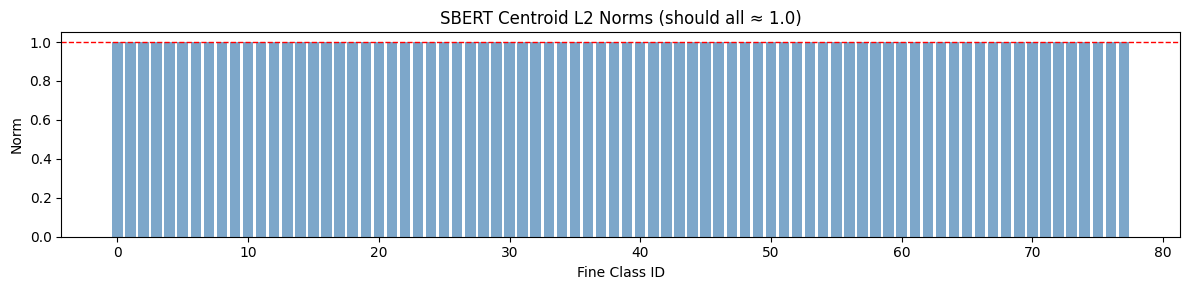

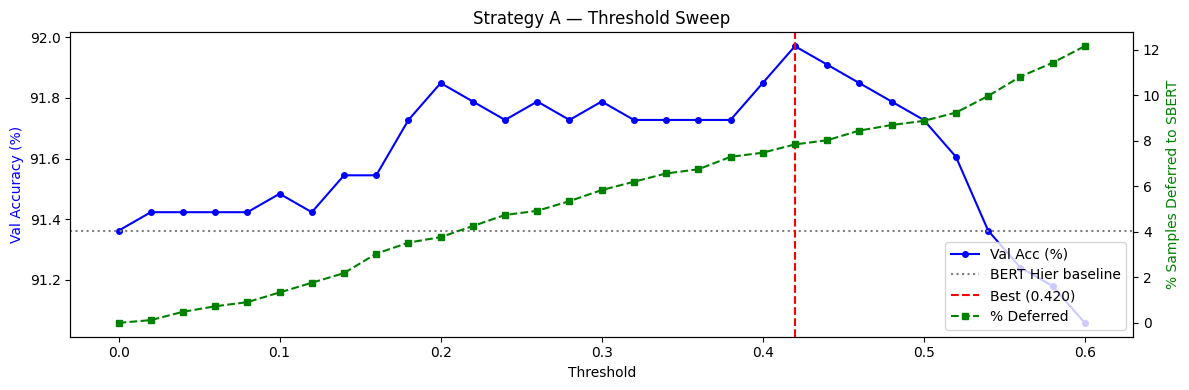

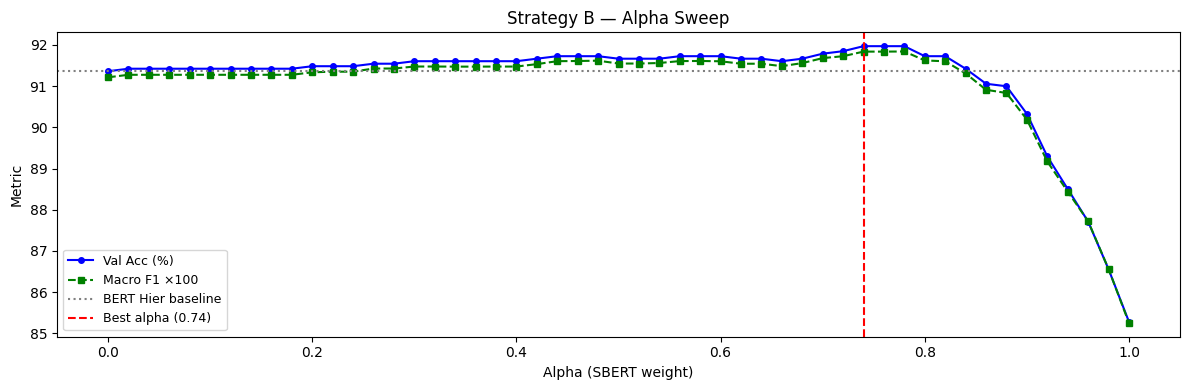

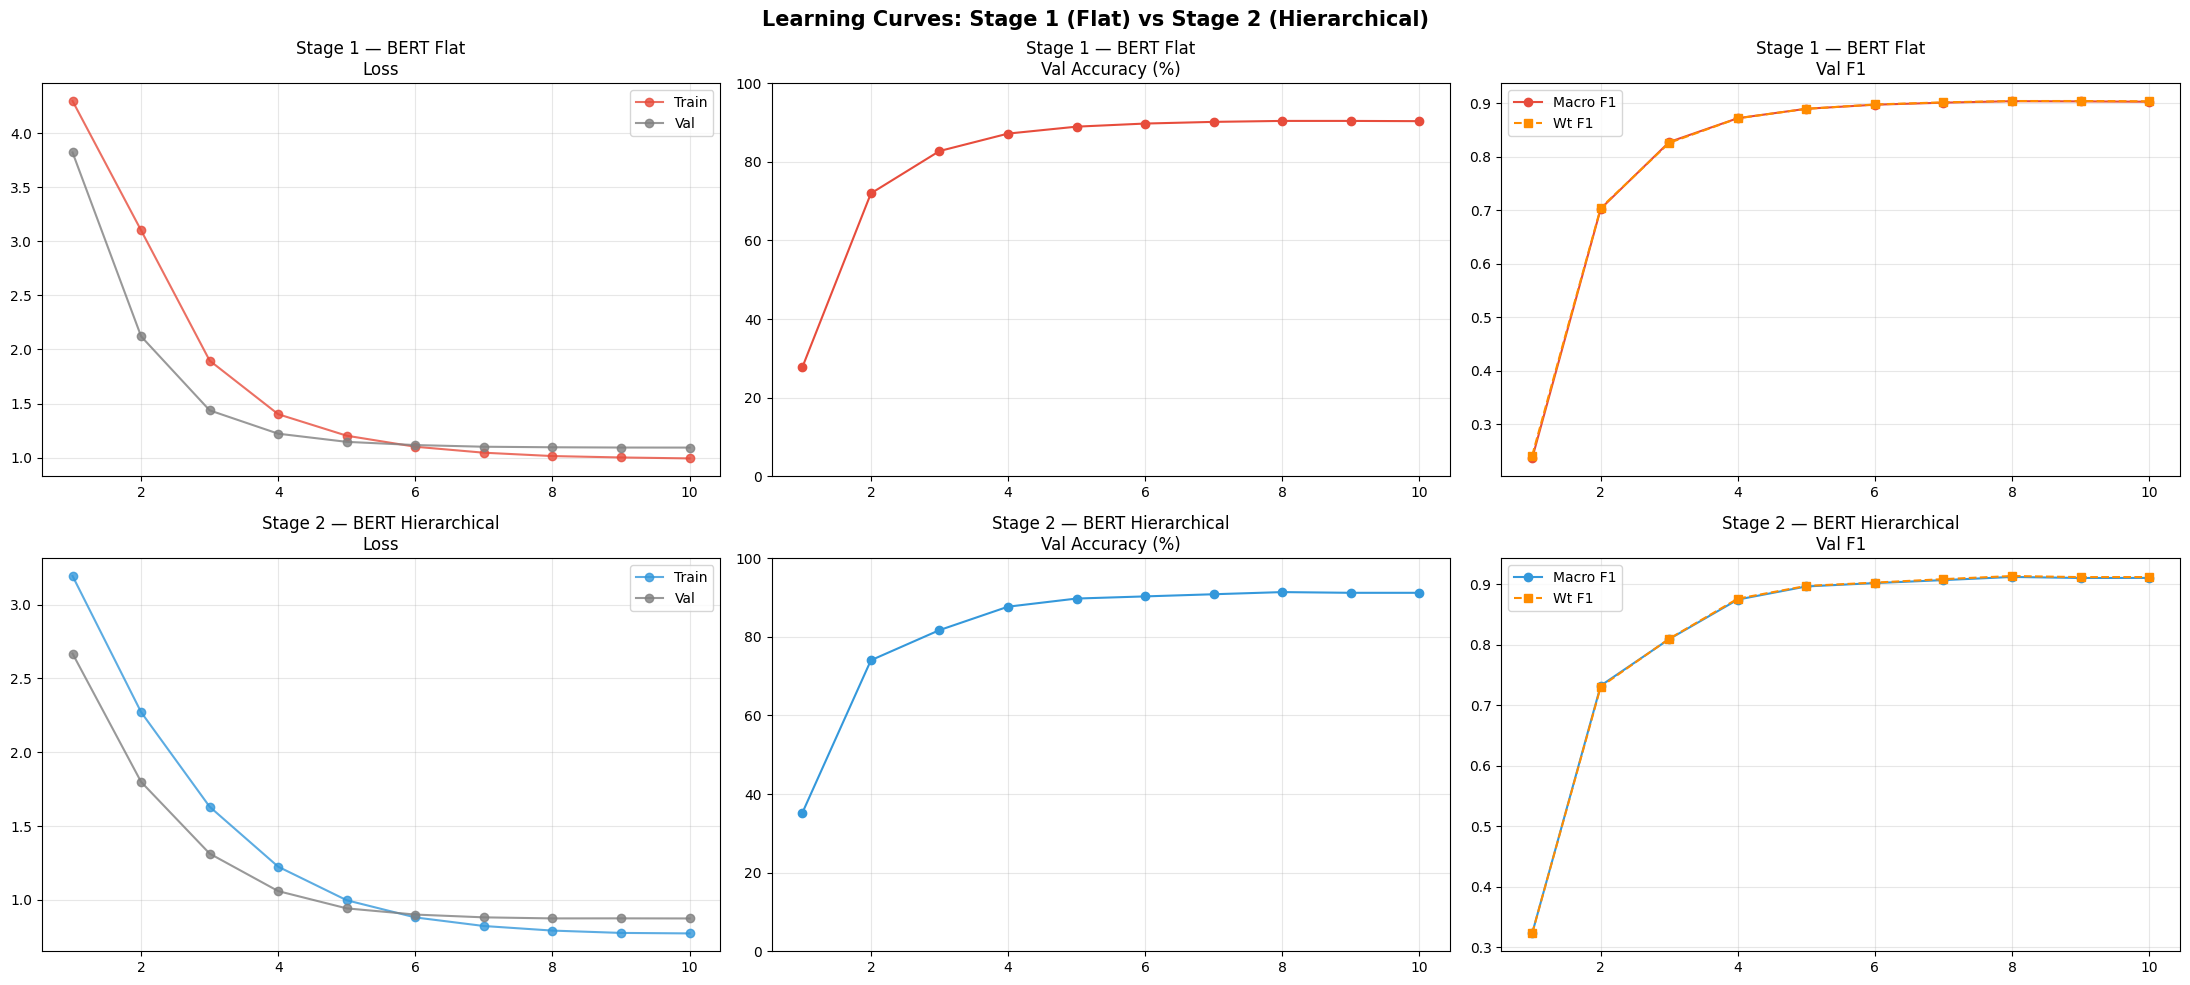

Saved: 03_learning_curves_s1_s2.png


In [36]:
%matplotlib inline
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle('Learning Curves: Stage 1 (Flat) vs Stage 2 (Hierarchical)', fontsize=15, fontweight='bold')

for row, (hist, stage_name, color) in enumerate([
    (history_flat, 'Stage 1 — BERT Flat',       '#e74c3c'),
    (history_hier, 'Stage 2 — BERT Hierarchical', '#3498db'),
]):
    ep = range(1, hist['epochs_ran'] + 1)
    axes[row, 0].plot(ep, hist['train_loss'], label='Train', marker='o', color=color, alpha=0.8)
    axes[row, 0].plot(ep, hist['val_loss'],   label='Val',   marker='o', color='gray',  alpha=0.8)
    axes[row, 0].set_title(f'{stage_name}\nLoss'); axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    axes[row, 1].plot(ep, [v*100 for v in hist['val_acc']], marker='o', color=color)
    axes[row, 1].set_title(f'{stage_name}\nVal Accuracy (%)'); axes[row, 1].grid(alpha=0.3)
    axes[row, 1].set_ylim(0, 100)

    axes[row, 2].plot(ep, hist['val_mf1'], marker='o', color=color, label='Macro F1')
    axes[row, 2].plot(ep, hist['val_wf1'], marker='s', color='darkorange', label='Wt F1', linestyle='--')
    axes[row, 2].set_title(f'{stage_name}\nVal F1'); axes[row, 2].legend(); axes[row, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_learning_curves_s1_s2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_learning_curves_s1_s2.png')


## 19. Evolution Bar Chart — All 4 Stages (Main Proof)

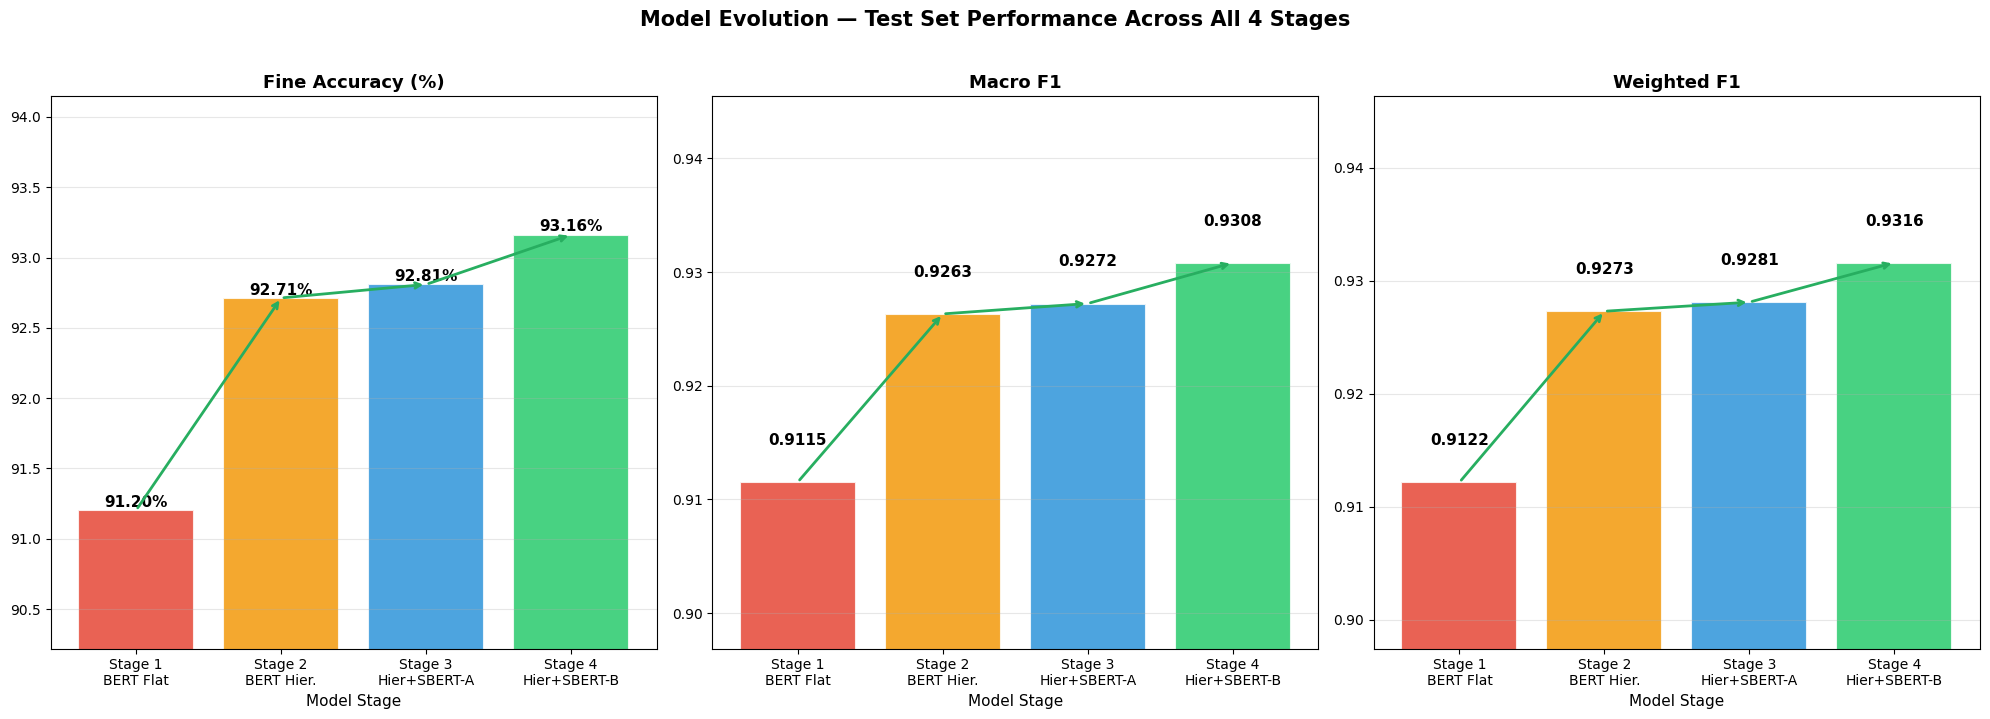

Saved: 04_evolution_bar_chart.png


In [37]:
stage_names   = ['Stage 1\nBERT Flat', 'Stage 2\nBERT Hier.', 'Stage 3\nHier+SBERT-A', 'Stage 4\nHier+SBERT-B']
accs          = [s1_acc, s2_acc, s3_acc, s4_acc]
mf1s          = [s1_mf1, s2_mf1, s3_mf1, s4_mf1]
wf1s          = [s1_wf1, s2_wf1, s3_wf1, s4_wf1]
colors_stage  = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Model Evolution — Test Set Performance Across All 4 Stages',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (vals, title, fmt) in zip(axes, [
    ([v*100 for v in accs], 'Fine Accuracy (%)', '{:.2f}%'),
    (mf1s,                  'Macro F1',          '{:.4f}'),
    (wf1s,                  'Weighted F1',       '{:.4f}'),
]):
    bars = ax.bar(stage_names, vals, color=colors_stage, alpha=0.88, edgecolor='white', linewidth=1.5)
    # Annotate bars
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                fmt.format(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    # Draw gain arrows between bars
    for i in range(1, len(vals)):
        gain = vals[i] - vals[i-1]
        mid_x = i - 0.5
        gain_color = '#27ae60' if gain >= 0 else '#c0392b'
        sign = '+' if gain >= 0 else ''
        ax.annotate('', xy=(i, vals[i]), xytext=(i-1, vals[i-1]),
                    arrowprops=dict(arrowstyle='->', color=gain_color, lw=2.0))
    # Zoom y-axis
    margin = (max(vals) - min(vals)) * 0.5 + 0.005
    ax.set_ylim(max(0, min(vals) - margin), min(max(vals) + margin, 100 if '%' in title else 1.01))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xlabel('Model Stage', fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_evolution_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_evolution_bar_chart.png')


## 20. Cumulative Gain Waterfall Chart

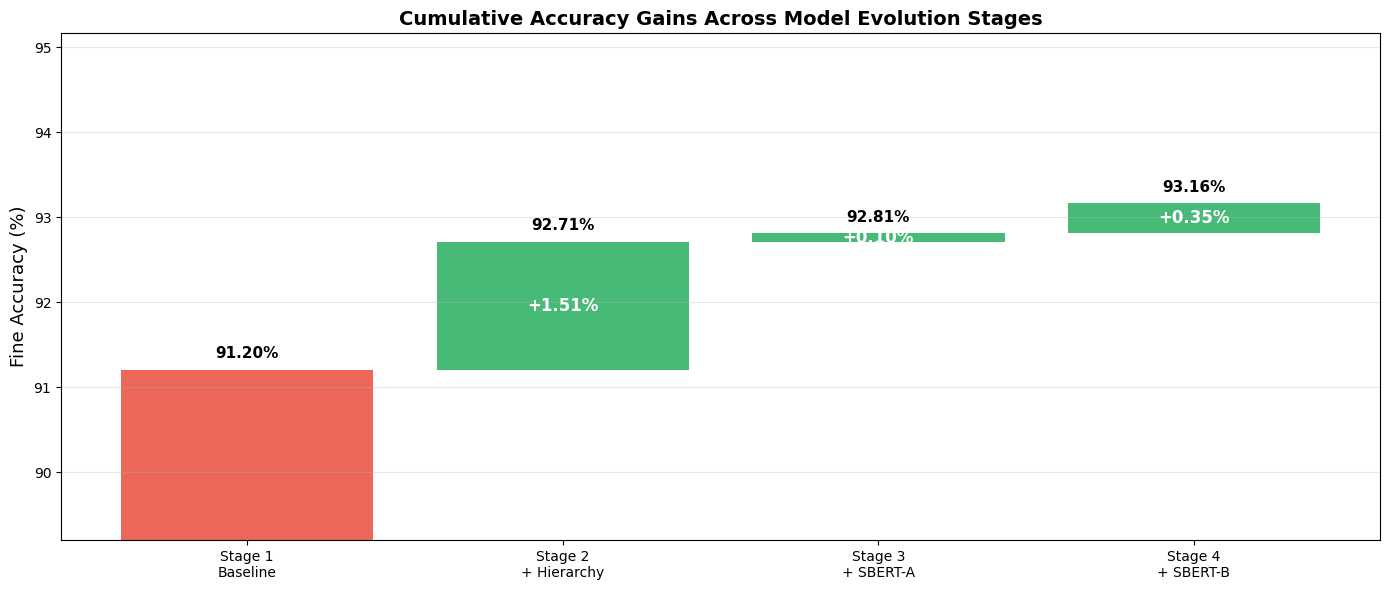

Saved: 05_cumulative_gains_waterfall.png


In [38]:
fig, ax = plt.subplots(figsize=(14, 6))
base_acc = s1_acc * 100
vals     = [s1_acc*100, s2_acc*100, s3_acc*100, s4_acc*100]
gains    = [0] + [vals[i] - vals[i-1] for i in range(1, len(vals))]
bottoms  = [0, vals[0], vals[1], vals[2]]

bar_colors = ['#e74c3c', '#27ae60' if gains[1]>=0 else '#c0392b',
               '#27ae60' if gains[2]>=0 else '#c0392b',
               '#27ae60' if gains[3]>=0 else '#c0392b']

labels_wf = ['Stage 1\nBaseline', 'Stage 2\n+ Hierarchy', 'Stage 3\n+ SBERT-A', 'Stage 4\n+ SBERT-B']
ax.bar(labels_wf[:1], [vals[0]], color=bar_colors[0], alpha=0.85, label='Baseline')
for i in range(1, 4):
    ax.bar(labels_wf[i], abs(gains[i]), bottom=bottoms[i], color=bar_colors[i], alpha=0.85)
    sign = '+' if gains[i] >= 0 else ''
    ax.text(i, bottoms[i] + abs(gains[i])/2, f'{sign}{gains[i]:.2f}%',
            ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# Annotate total heights
for i, (lbl, v) in enumerate(zip(labels_wf, vals)):
    ax.text(i, v + 0.1, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Fine Accuracy (%)', fontsize=13)
ax.set_title('Cumulative Accuracy Gains Across Model Evolution Stages', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ymin = min(vals) - 2
ax.set_ylim(ymin, max(vals) + 2)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_cumulative_gains_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_cumulative_gains_waterfall.png')


## 21. Per-Class F1 Comparison — All 4 Stages

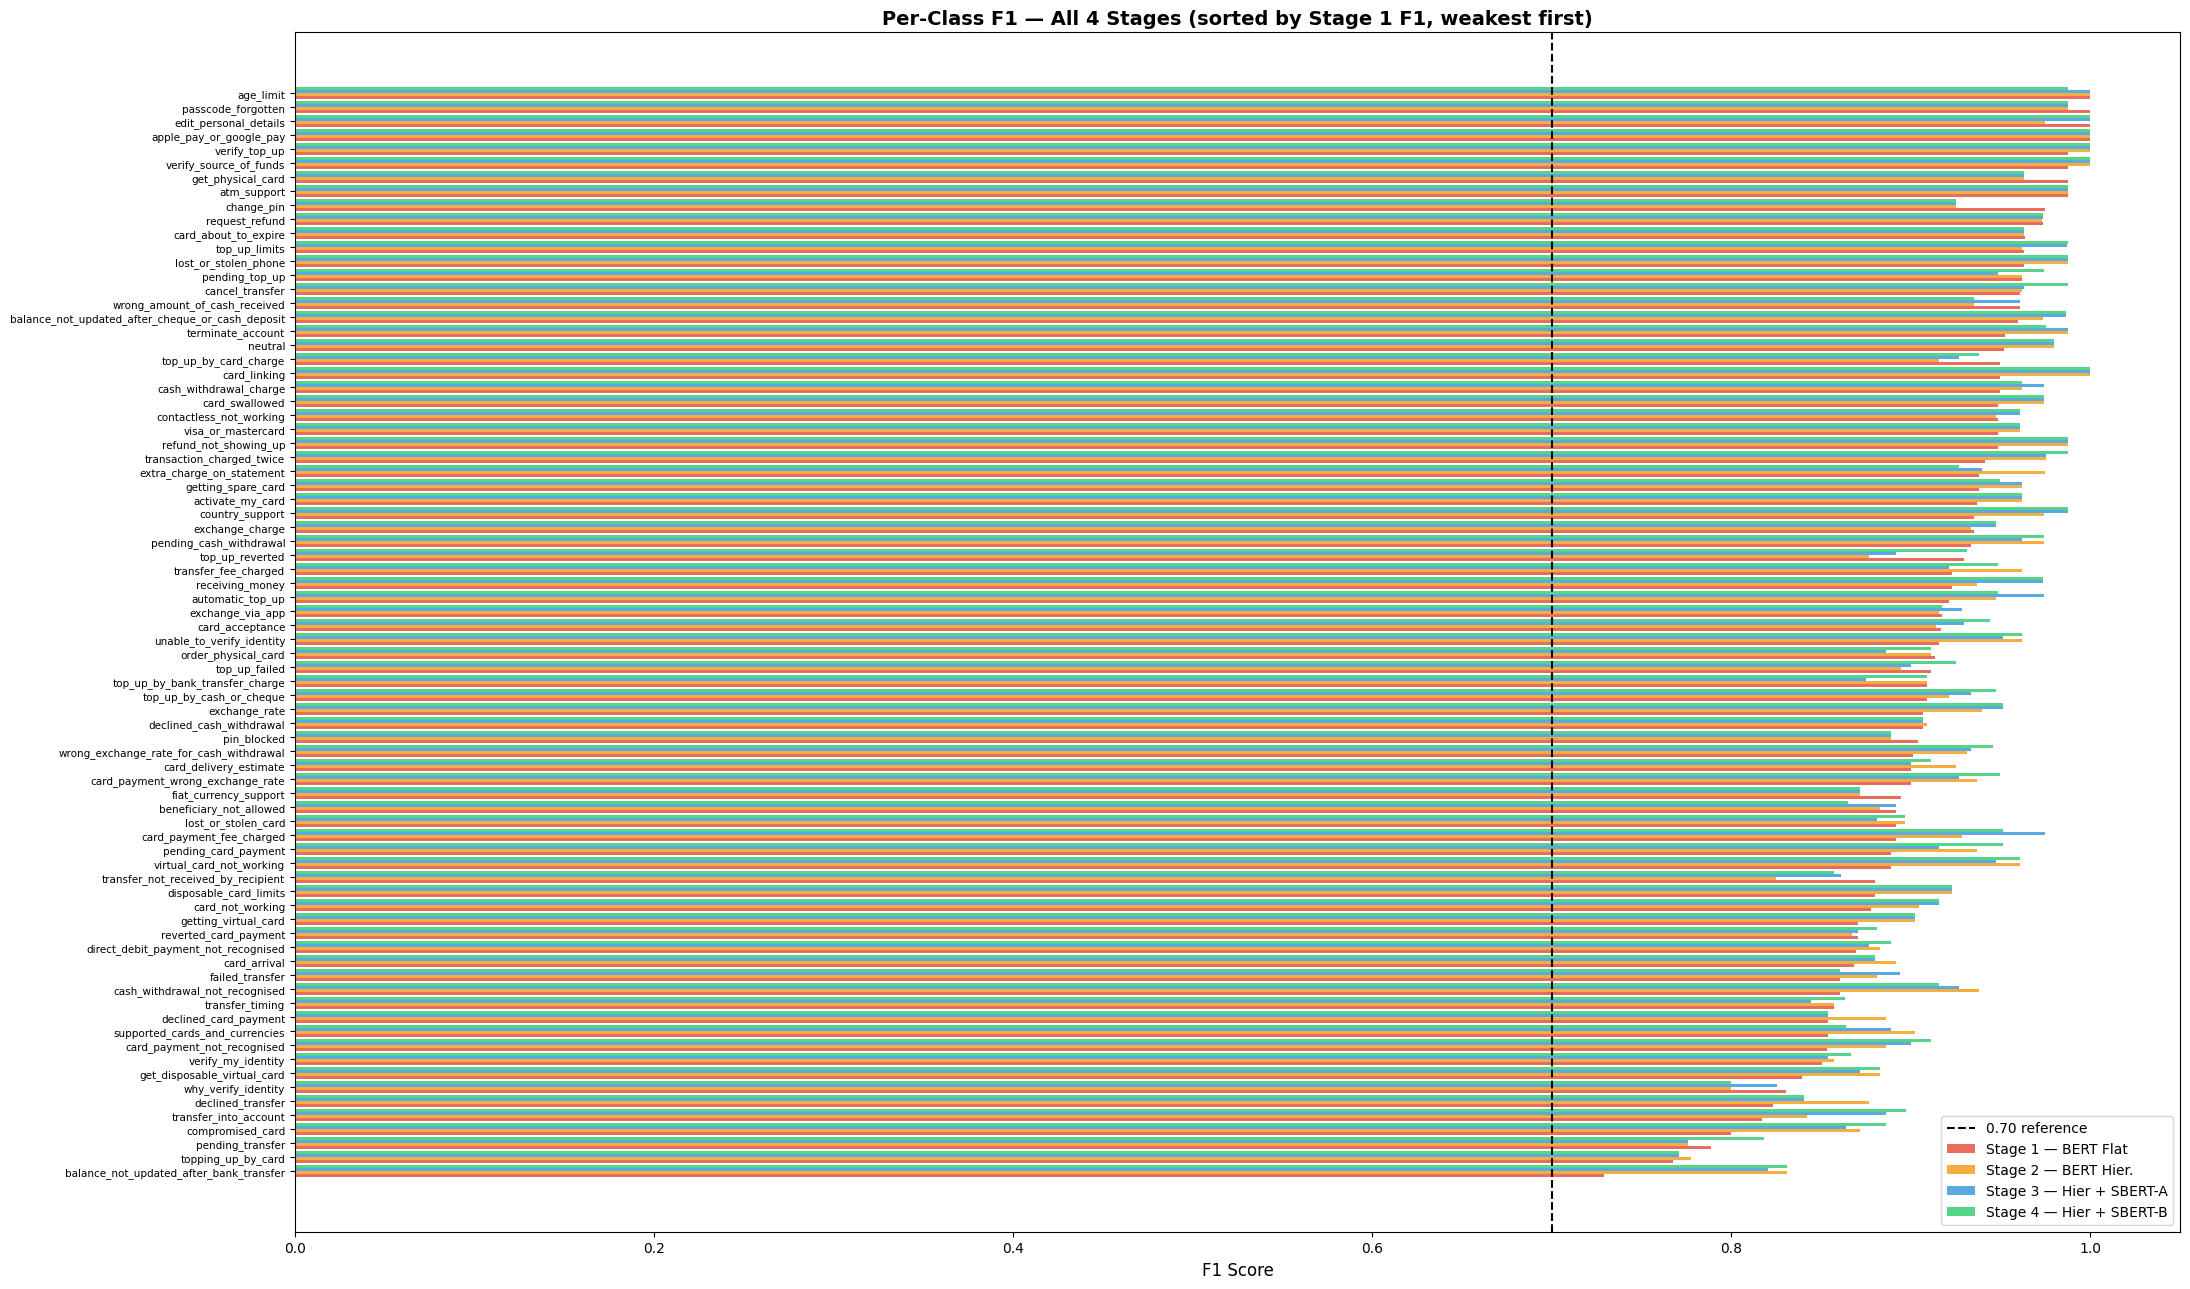

Saved: 06_per_class_f1_all_stages.png


In [39]:
def get_class_f1(labels, preds):
    rd = classification_report(labels, preds, target_names=fine_le.classes_,
                                output_dict=True, zero_division=0)
    return np.array([rd[c]['f1-score'] for c in fine_le.classes_])

f1_s1 = get_class_f1(s1_labels, s1_preds)
f1_s2 = get_class_f1(s2_labels, s2_preds)
f1_s3 = get_class_f1(test_labels, s3_preds)
f1_s4 = get_class_f1(test_labels, s4_preds)

# Sort by Stage 1 F1 (weakest first)
order = np.argsort(f1_s1)
class_names_sorted = fine_le.classes_[order]

fig, ax = plt.subplots(figsize=(22, 13))
y  = np.arange(NUM_FINE)
bw = 0.22
ax.barh(y - 1.5*bw, f1_s1[order], bw, label='Stage 1 — BERT Flat',       color='#e74c3c', alpha=0.82)
ax.barh(y - 0.5*bw, f1_s2[order], bw, label='Stage 2 — BERT Hier.',       color='#f39c12', alpha=0.82)
ax.barh(y + 0.5*bw, f1_s3[order], bw, label='Stage 3 — Hier + SBERT-A',   color='#3498db', alpha=0.82)
ax.barh(y + 1.5*bw, f1_s4[order], bw, label='Stage 4 — Hier + SBERT-B',   color='#2ecc71', alpha=0.82)
ax.set_yticks(y); ax.set_yticklabels(class_names_sorted, fontsize=7.5)
ax.axvline(0.70, color='black', linestyle='--', lw=1.5, label='0.70 reference')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 — All 4 Stages (sorted by Stage 1 F1, weakest first)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_per_class_f1_all_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_per_class_f1_all_stages.png')


## 22. SBERT Similarity Distribution — Evidence SBERT Can Help

Mean SBERT sim — BERT correct  : 0.7694
Mean SBERT sim — BERT incorrect: 0.6349


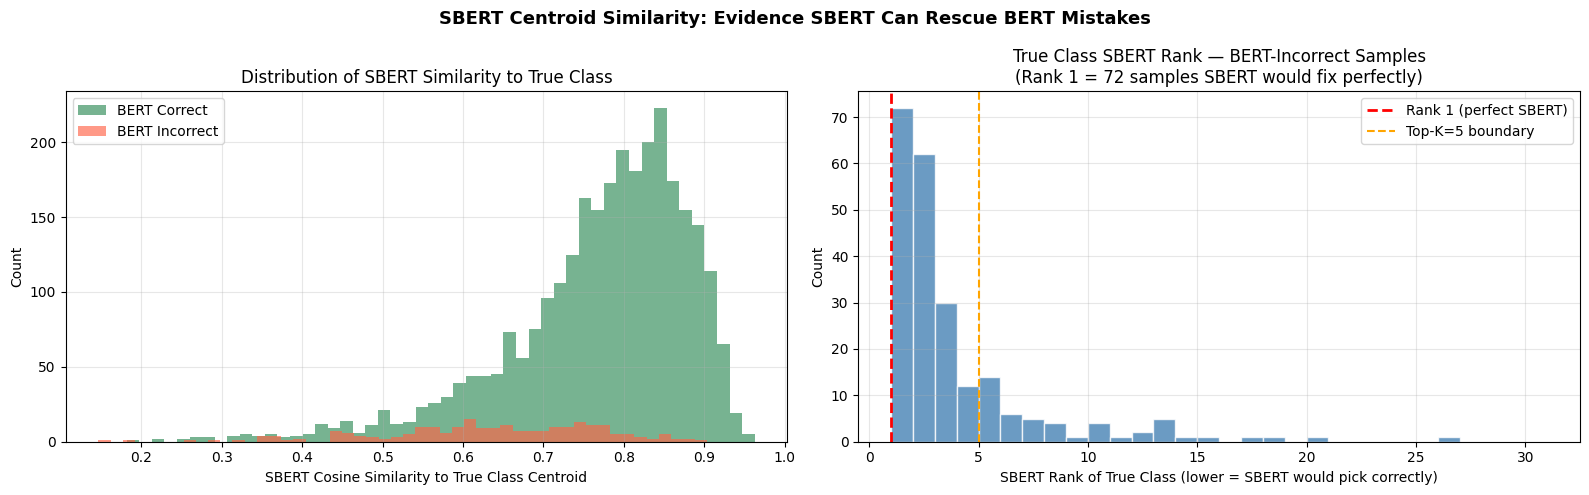

Saved: 07_sbert_similarity_evidence.png

SBERT would rank true class 1st for 72 / 227 BERT-incorrect samples
SBERT would rank true class in top-5 for 190 / 227 BERT-incorrect samples


In [40]:
# Key plot: BERT-incorrect samples should still have high SBERT sim to the TRUE class.
# If they do, SBERT routing will fix them.

true_sims = np.array([
    test_sbert_embs[i] @ centroid_matrix[test_labels[i]]
    for i in range(len(test_labels))
])
s2_correct_mask = np.array(s2_preds) == test_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('SBERT Centroid Similarity: Evidence SBERT Can Rescue BERT Mistakes',
             fontsize=13, fontweight='bold')

axes[0].hist(true_sims[s2_correct_mask],  bins=50, alpha=0.65, color='seagreen', label='BERT Correct')
axes[0].hist(true_sims[~s2_correct_mask], bins=50, alpha=0.65, color='tomato',   label='BERT Incorrect')
axes[0].set_xlabel('SBERT Cosine Similarity to True Class Centroid')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of SBERT Similarity to True Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

print(f'Mean SBERT sim — BERT correct  : {true_sims[s2_correct_mask].mean():.4f}')
print(f'Mean SBERT sim — BERT incorrect: {true_sims[~s2_correct_mask].mean():.4f}')

# SBERT rank of the true class for BERT-incorrect samples
all_sims = test_sbert_embs @ centroid_matrix.T
ranks = []
for i in np.where(~s2_correct_mask)[0]:
    sorted_classes = np.argsort(all_sims[i])[::-1]
    rank = np.where(sorted_classes == test_labels[i])[0][0] + 1
    ranks.append(rank)
ranks = np.array(ranks)

axes[1].hist(ranks, bins=range(1, min(30, max(ranks))+2), color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('SBERT Rank of True Class (lower = SBERT would pick correctly)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'True Class SBERT Rank — BERT-Incorrect Samples\n'
                  f'(Rank 1 = {(ranks==1).sum()} samples SBERT would fix perfectly)')
axes[1].axvline(1, color='red', linestyle='--', lw=2, label='Rank 1 (perfect SBERT)')
axes[1].axvline(SBERT_TOP_K, color='orange', linestyle='--', lw=1.5, label=f'Top-K={SBERT_TOP_K} boundary')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/07_sbert_similarity_evidence.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: 07_sbert_similarity_evidence.png')
print(f'\nSBERT would rank true class 1st for {(ranks==1).sum()} / {len(ranks)} BERT-incorrect samples')
print(f'SBERT would rank true class in top-{SBERT_TOP_K} for {(ranks<=SBERT_TOP_K).sum()} / {len(ranks)} BERT-incorrect samples')


## 23. Confusion Matrices — Coarse Level (Stage 2 & Best Ensemble)

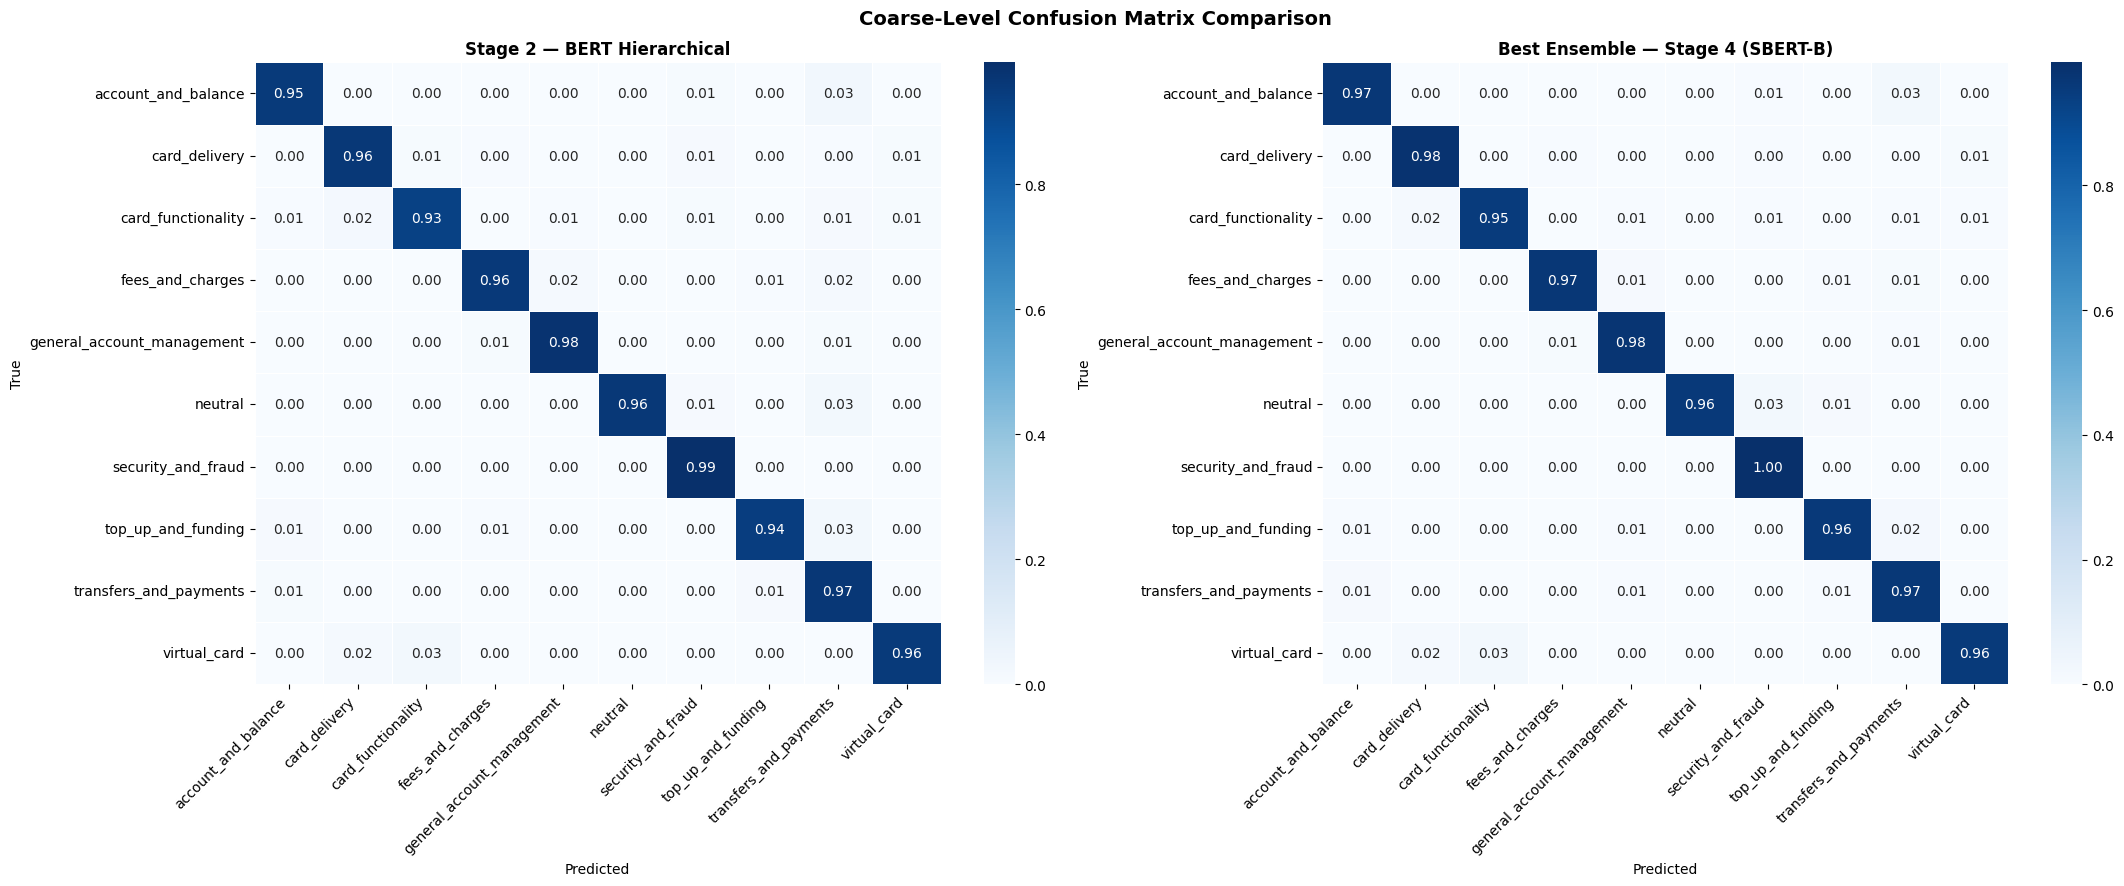

Saved: 08_coarse_confusion_matrices.png


In [41]:
fine_to_coarse_map = {}
for v, c in id2fine.items():
    cn = coarse_mapping.get(c, 'neutral')
    fine_to_coarse_map[int(v)] = int(coarse_le.transform([cn])[0])

best_ens_preds = s3_preds if s3_acc >= s4_acc else s4_preds
best_ens_name  = 'Stage 3 (SBERT-A)' if s3_acc >= s4_acc else 'Stage 4 (SBERT-B)'
best_ens_coarse = np.array([fine_to_coarse_map[p] for p in best_ens_preds])

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for ax, (preds_c, title) in zip(axes, [
    (np.array(s2_cpreds),   'Stage 2 — BERT Hierarchical'),
    (best_ens_coarse,       f'Best Ensemble — {best_ens_name}'),
]):
    cm = confusion_matrix(test_clabels, preds_c, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=coarse_le.classes_, yticklabels=coarse_le.classes_,
                linewidths=0.5, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Coarse-Level Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/08_coarse_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_coarse_confusion_matrices.png')


## 24. Error Analysis — Where SBERT Helps vs Hurts (vs Stage 2)


── Stage 3 (Strategy A) vs Stage 2 ──
  Both correct : 2,854
  SBERT helped :   37  (+1.2%)
  SBERT hurt   :   34  (-1.1%)
  Both wrong   :  190
  Net gain     :   +3 samples


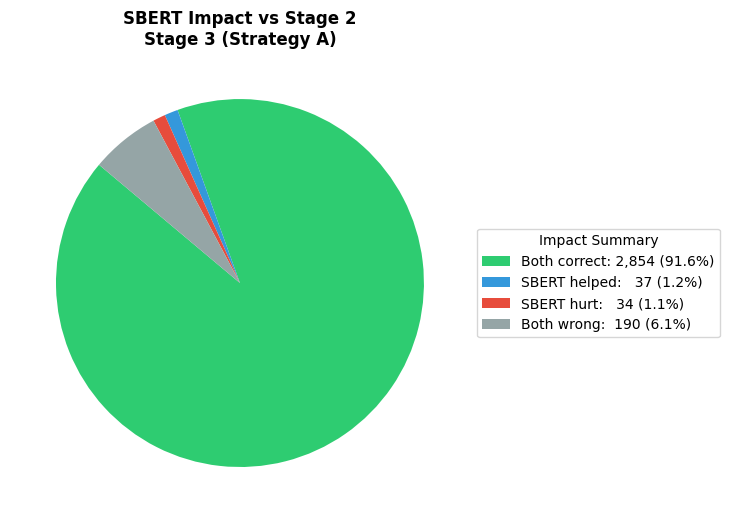

  Error CSV saved.

── Stage 4 (Strategy B) vs Stage 2 ──
  Both correct : 2,866
  SBERT helped :   36  (+1.2%)
  SBERT hurt   :   22  (-0.7%)
  Both wrong   :  191
  Net gain     :  +14 samples


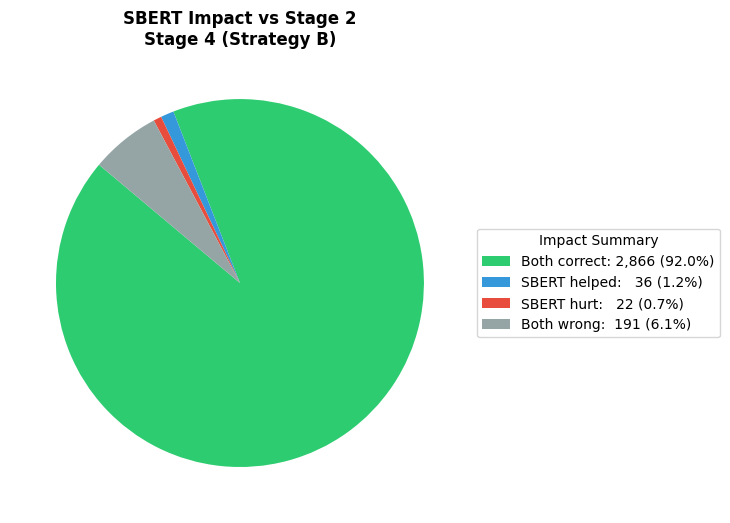

  Error CSV saved.


In [42]:
import matplotlib.pyplot as plt
import numpy as np


def sbert_impact(
    test_df, s2_preds_arr, ens_preds, ens_name, fine_le, save_prefix
):
    df = test_df[["text", "category", "coarse_category"]].copy()
    df["s2_pred"] = [fine_le.classes_[p] for p in s2_preds_arr]
    df["ens_pred"] = [fine_le.classes_[p] for p in ens_preds]
    df["s2_ok"] = df["category"] == df["s2_pred"]
    df["ens_ok"] = df["category"] == df["ens_pred"]
    df["helped"] = (~df["s2_ok"]) & df["ens_ok"]
    df["hurt"] = df["s2_ok"] & (~df["ens_ok"])

    total_samples = len(df)
    both_ok = (df["s2_ok"] & df["ens_ok"]).sum()
    both_bad = (~df["s2_ok"] & ~df["ens_ok"]).sum()
    helped = df["helped"].sum()
    hurt = df["hurt"].sum()

    print(f"\n── {ens_name} vs Stage 2 ──")
    print(f"  Both correct : {both_ok:4,}")
    print(f"  SBERT helped : {helped:4,}  (+{helped/total_samples*100:.1f}%)")
    print(f"  SBERT hurt   : {hurt:4,}  (-{hurt/total_samples*100:.1f}%)")
    print(f"  Both wrong   : {both_bad:4,}")
    print(f"  Net gain     : {helped-hurt:+4,} samples")

    # ── Pie Chart Configuration ──
    fig, ax = plt.subplots(figsize=(7, 6))  # Slightly wider to fit the legend
    sizes = [both_ok, helped, hurt, both_bad]
    base_labels = ["Both correct", "SBERT helped", "SBERT hurt", "Both wrong"]
    colors = ["#2ecc71", "#3498db", "#e74c3c", "#95a5a6"]

    # 1. Plot pie without external labels and without inside numbers
    wedges, texts = ax.pie(
        sizes,
        colors=colors,
        startangle=140,
    )

    # 2. Create detailed labels combining name, count, and percentage
    legend_labels = []
    for label, size in zip(base_labels, sizes):
        percentage = (size / total_samples) * 100
        legend_labels.append(f"{label}: {size:4,} ({percentage:.1f}%)")

    # 3. Add the legend outside the chart, mapped to the wedge colors
    ax.legend(
        wedges,
        legend_labels,
        title="Impact Summary",
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),  # Positions legend perfectly to the right
        fontsize=10,
    )

    ax.set_title(
        f"SBERT Impact vs Stage 2\n{ens_name}", fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        f"{PLOTS_DIR}/{save_prefix}_sbert_impact.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()

    df.to_csv(f"{OUTPUT_DIR}/errors_{save_prefix}.csv", index=False)
    print(f"  Error CSV saved.")
    return df


# ── Execution ──
s2_preds_arr = np.array(s2_preds)
df_a = sbert_impact(
    test_df,
    s2_preds_arr,
    s3_preds,
    "Stage 3 (Strategy A)",
    fine_le,
    "09_stage3",
)
df_b = sbert_impact(
    test_df,
    s2_preds_arr,
    s4_preds,
    "Stage 4 (Strategy B)",
    fine_le,
    "10_stage4",
)

## 25. Coarse-Category Accuracy Breakdown — All Stages

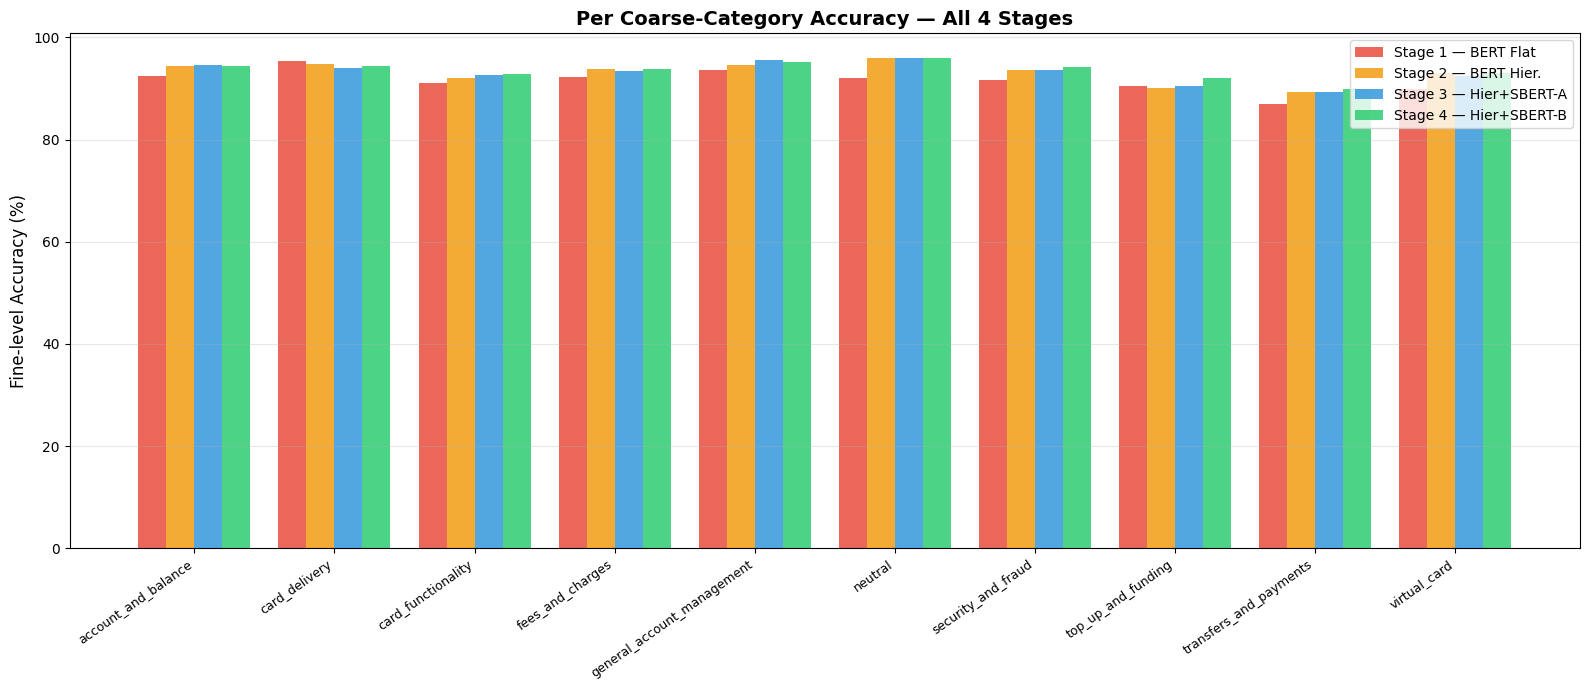

Saved: 11_coarse_category_accuracy_all_stages.png


In [43]:
fig, ax = plt.subplots(figsize=(16, 7))
x  = np.arange(NUM_COARSE)
bw = 0.20

def coarse_accs_from_fine(labels, preds, coarse_labels):
    accs = []
    for ci in range(NUM_COARSE):
        mask = coarse_labels == ci
        if mask.sum() == 0: accs.append(0.0); continue
        accs.append(accuracy_score(labels[mask], preds[mask]))
    return accs

s1_ca = coarse_accs_from_fine(np.array(s1_labels), np.array(s1_preds), test_clabels)
s2_ca = coarse_accs_from_fine(test_labels, np.array(s2_preds), test_clabels)
s3_ca = coarse_accs_from_fine(test_labels, s3_preds, test_clabels)
s4_ca = coarse_accs_from_fine(test_labels, s4_preds, test_clabels)

ax.bar(x - 1.5*bw, [v*100 for v in s1_ca], bw, label='Stage 1 — BERT Flat',     color='#e74c3c', alpha=0.85)
ax.bar(x - 0.5*bw, [v*100 for v in s2_ca], bw, label='Stage 2 — BERT Hier.',     color='#f39c12', alpha=0.85)
ax.bar(x + 0.5*bw, [v*100 for v in s3_ca], bw, label='Stage 3 — Hier+SBERT-A',  color='#3498db', alpha=0.85)
ax.bar(x + 1.5*bw, [v*100 for v in s4_ca], bw, label='Stage 4 — Hier+SBERT-B',  color='#2ecc71', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([id2coarse[i] for i in range(NUM_COARSE)], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Fine-level Accuracy (%)', fontsize=12)
ax.set_title('Per Coarse-Category Accuracy — All 4 Stages', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/11_coarse_category_accuracy_all_stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_coarse_category_accuracy_all_stages.png')


## 26. Final Summary Table — All Metrics

In [44]:
summary_data = {
    'Stage':       ['Stage 1\nBERT Flat', 'Stage 2\nBERT Hier.', 'Stage 3\nHier+SBERT-A', 'Stage 4\nHier+SBERT-B'],
    'Accuracy (%)': [round(s1_acc*100,2), round(s2_acc*100,2), round(s3_acc*100,2), round(s4_acc*100,2)],
    'Macro F1':     [round(s1_mf1,4), round(s2_mf1,4), round(s3_mf1,4), round(s4_mf1,4)],
    'Weighted F1':  [round(s1_wf1,4), round(s2_wf1,4), round(s3_wf1,4), round(s4_wf1,4)],
}
summary_df = pd.DataFrame(summary_data)
summary_df['Acc Gain vs prev'] = ['—'] + [f'{summary_df["Accuracy (%)"][i]-summary_df["Accuracy (%)"][i-1]:+.2f}%'
                                            for i in range(1, 4)]
summary_df['MF1 Gain vs prev'] = ['—'] + [f'{summary_df["Macro F1"][i]-summary_df["Macro F1"][i-1]:+.4f}'
                                            for i in range(1, 4)]
print('\n' + '='*80)
print('FINAL SUMMARY TABLE')
print('='*80)
print(summary_df.to_string(index=False))
print('='*80)

summary_df.to_csv(f'{OUTPUT_DIR}/final_summary_table.csv', index=False)
print('\nSummary table saved.')



FINAL SUMMARY TABLE
                Stage  Accuracy (%)  Macro F1  Weighted F1 Acc Gain vs prev MF1 Gain vs prev
   Stage 1\nBERT Flat         91.20    0.9115       0.9122                —                —
  Stage 2\nBERT Hier.         92.71    0.9263       0.9273           +1.51%          +0.0148
Stage 3\nHier+SBERT-A         92.81    0.9272       0.9281           +0.10%          +0.0009
Stage 4\nHier+SBERT-B         93.16    0.9308       0.9316           +0.35%          +0.0036

Summary table saved.


---
## 27. Save Everything to ZIP for Inference

In [45]:
import os, zipfile

MODEL_ZIP = '/kaggle/working/MODEL_bert_sbert_banking77.zip'
PLOTS_ZIP = '/kaggle/working/PLOTS_bert_sbert_banking77.zip'

# Clean stale zips
for z in [MODEL_ZIP, PLOTS_ZIP]:
    if os.path.exists(z): os.remove(z); print(f'Deleted: {os.path.basename(z)}')

# Model zip
model_files = [
    'best_flat.pt', 'best_hier.pt',
    'sbert_centroids.npy',
    'id2fine.json', 'id2coarse.json',
    'coarse_to_fine_ids.json', 'coarse_mapping.json',
    'final_summary.json', 'final_summary_table.csv',
    'history_flat.json', 'history_hier.json',
    'report_stage1_flat.txt', 'report_stage2_hier.txt',
    'report_stage3_sbert_a.txt', 'report_stage4_sbert_b.txt',
]
print('\nCreating Model Archive...')
with zipfile.ZipFile(MODEL_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in model_files:
        fpath = f'{OUTPUT_DIR}/{fname}'
        if os.path.exists(fpath):
            zf.write(fpath, fname); print(f'  ✓ {fname}')
        else:
            print(f'  ✗ MISSING: {fname}')
    tok_dir = f'{OUTPUT_DIR}/tokenizer'
    if os.path.isdir(tok_dir):
        for tok_file in os.listdir(tok_dir):
            zf.write(os.path.join(tok_dir, tok_file), f'tokenizer/{tok_file}')
        print('  ✓ tokenizer/')

# Plots zip
print('\nCreating Plots Archive...')
with zipfile.ZipFile(PLOTS_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    if os.path.exists(PLOTS_DIR):
        for fname in sorted(os.listdir(PLOTS_DIR)):
            fpath = os.path.join(PLOTS_DIR, fname)
            if os.path.isfile(fpath):
                zf.write(fpath, fname); print(f'  ✓ {fname}')

print('\n── Artifact sizes ──')
for fpath in [MODEL_ZIP, PLOTS_ZIP]:
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f'  {os.path.basename(fpath):<45} {size:>8.1f} MB')
print('\nDone! Refresh the Kaggle Output tab to download.')



Creating Model Archive...
  ✓ best_flat.pt
  ✓ best_hier.pt
  ✓ sbert_centroids.npy
  ✓ id2fine.json
  ✓ id2coarse.json
  ✓ coarse_to_fine_ids.json
  ✓ coarse_mapping.json
  ✓ final_summary.json
  ✓ final_summary_table.csv
  ✓ history_flat.json
  ✓ history_hier.json
  ✓ report_stage1_flat.txt
  ✓ report_stage2_hier.txt
  ✓ report_stage3_sbert_a.txt
  ✓ report_stage4_sbert_b.txt

Creating Plots Archive...
  ✓ 00_centroid_norms.png
  ✓ 01_strategy_a_threshold_sweep.png
  ✓ 02_strategy_b_alpha_sweep.png
  ✓ 03_learning_curves_s1_s2.png
  ✓ 04_evolution_bar_chart.png
  ✓ 05_cumulative_gains_waterfall.png
  ✓ 06_per_class_f1_all_stages.png
  ✓ 07_sbert_similarity_evidence.png
  ✓ 08_coarse_confusion_matrices.png
  ✓ 09_stage3_sbert_impact.png
  ✓ 10_stage4_sbert_impact.png
  ✓ 11_coarse_category_accuracy_all_stages.png

── Artifact sizes ──
  MODEL_bert_sbert_banking77.zip                  1219.6 MB
  PLOTS_bert_sbert_banking77.zip                     1.3 MB

Done! Refresh the Kaggle Outpu

---
## 28. Inference Helper — Load & Predict Across All Stages

Load any saved stage and run predictions on new texts.

In [46]:
def strategy_a_predict(probs, sbert_embs, centroids, threshold, top_k=5):
    sorted_idx = np.argsort(probs, axis=-1)[:, ::-1]
    gap = probs[np.arange(len(probs)), sorted_idx[:, 0]] - probs[np.arange(len(probs)), sorted_idx[:, 1]]
    final = sorted_idx[:, 0].copy()
    for i in np.where(gap < threshold)[0]:
        cands = sorted_idx[i, :top_k]
        final[i] = cands[(centroids[cands] @ sbert_embs[i]).argmax()]
    return final

def strategy_b_predict(probs, sbert_embs, centroids, alpha):
    sims = sbert_embs @ centroids.T
    sn   = (sims - sims.min(1, keepdims=True)) / (sims.max(1, keepdims=True) - sims.min(1, keepdims=True) + 1e-8)
    return ((1 - alpha) * probs + alpha * sn).argmax(axis=-1)

def predict_all_stages(texts, hier_model, flat_model, tokenizer, sbert_model,
                        centroid_matrix, id2fine, coarse_to_fine_ids,
                        conf_threshold, fusion_alpha, max_len, device, batch_size=32):
    """Run texts through all 4 stages and return a DataFrame of predictions."""
    # Stage 1 — flat
    flat_model.eval()
    flat_preds = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenizer(texts[i:i+batch_size], max_length=max_len, padding='max_length',
                            truncation=True, return_tensors='pt')
            logits = flat_model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
            flat_preds.extend(logits.argmax(-1).cpu().numpy())

    # Stages 2-4 — hierarchical
    hier_model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tokenizer(texts[i:i+batch_size], max_length=max_len, padding='max_length',
                            truncation=True, return_tensors='pt')
            ids_b  = enc['input_ids'].to(device)
            mask_b = enc['attention_mask'].to(device)
            cl_logits, fl_logits = hier_model(ids_b, mask_b)
            cp = cl_logits.argmax(-1).cpu().numpy()
            masked = fl_logits.clone()
            for j, c in enumerate(cp):
                mv = torch.full((fl_logits.size(1),), float('-inf'), device=device)
                mv[coarse_to_fine_ids[int(c)]] = 0.0
                masked[j] += mv
            all_probs.append(F.softmax(masked, -1).cpu().numpy())
    all_probs = np.vstack(all_probs)

    sbert_embs = sbert_model.encode(texts, batch_size=64, normalize_embeddings=True, convert_to_numpy=True)
    s3_preds_inf = strategy_a_predict(all_probs, sbert_embs, centroid_matrix, conf_threshold)
    s4_preds_inf = strategy_b_predict(all_probs, sbert_embs, centroid_matrix, fusion_alpha)

    return pd.DataFrame({
        'text':    texts,
        'Stage1_flat':        [id2fine[p] for p in flat_preds],
        'Stage2_hier':        [id2fine[p] for p in all_probs.argmax(-1)],
        'Stage3_hier_sbert_a':[id2fine[p] for p in s3_preds_inf],
        'Stage4_hier_sbert_b':[id2fine[p] for p in s4_preds_inf],
    })


# ── Quick demo ─────────────────────────────────────────────────────────────────
sample_texts = [
    'My card was swallowed by the ATM, what do I do?',
    'I was charged twice for the same transaction.',
    'How long does it take for a new card to arrive?',
    'I forgot my passcode and now I am locked out.',
    'Can I use Apple Pay with my account?',
    'Why was my top-up rejected?',
    'I need to change my personal details.',
    'What currencies does my account support?',
]

flat_ref = flat_model.module if hasattr(flat_model, 'module') else flat_model
hier_ref_inf = hier_model.module if hasattr(hier_model, 'module') else hier_model
flat_ref.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_flat.pt'))
hier_ref_inf.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_hier.pt'))
flat_ref.eval(); hier_ref_inf.eval()

demo_df = predict_all_stages(
    sample_texts, hier_ref_inf, flat_ref, tokenizer, sbert_model,
    centroid_matrix, id2fine, coarse_to_fine_ids,
    CONF_THRESHOLD, FUSION_ALPHA, MAX_LEN, DEVICE
)
print('\nDemo predictions across all stages:')
print(demo_df.to_string(index=False))



Demo predictions across all stages:
                                           text               Stage1_flat               Stage2_hier       Stage3_hier_sbert_a       Stage4_hier_sbert_b
My card was swallowed by the ATM, what do I do?            card_swallowed            card_swallowed            card_swallowed            card_swallowed
  I was charged twice for the same transaction. transaction_charged_twice transaction_charged_twice transaction_charged_twice transaction_charged_twice
How long does it take for a new card to arrive?              card_arrival              card_arrival              card_arrival              card_arrival
  I forgot my passcode and now I am locked out.        passcode_forgotten        passcode_forgotten        passcode_forgotten        passcode_forgotten
           Can I use Apple Pay with my account?   apple_pay_or_google_pay   apple_pay_or_google_pay   apple_pay_or_google_pay   apple_pay_or_google_pay
                    Why was my top-up rejected?    

In [57]:
print("start")
# ── EVALUATION CELL: Test best model on real calls JSON ───────────────────────
import json
import numpy as np
import torch
import torch.nn.functional as F
from collections import Counter, defaultdict

CALLS_PATH = '/kaggle/working/calls_clean.json'

# Load calls
with open(CALLS_PATH, 'r') as f:
    calls_data = json.load(f)

# Extract true intent AND call quality from call type
def parse_call_type(call_type):
    suffixes = ['_good', '_bad', '_ambiguous', '_recovery', '_incomplete', '_noise']
    for s in suffixes:
        if call_type.endswith(s):
            return call_type[:-len(s)], s[1:]  # intent, quality
    return call_type, 'unknown'

def predict_call(turns, tokenizer, model, centroid_matrix, c2f, device, alpha):
    if not turns:
        return None, 0.0, []

    encodings = tokenizer(
        turns,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    ids  = encodings['input_ids'].to(device)
    mask = encodings['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        cl_logits, fl_logits = model(ids, mask)
        coarse_probs = F.softmax(cl_logits, dim=-1)
        fine_gate = torch.zeros(fl_logits.size(0), fl_logits.size(1), device=device)
        for coarse_id, fine_ids in c2f.items():
            fine_gate[:, fine_ids] += coarse_probs[:, coarse_id].unsqueeze(1)
        gated_logits = fl_logits + torch.log(fine_gate.clamp(min=1e-8))
        bert_probs   = F.softmax(gated_logits, dim=-1).cpu().numpy()

    # SBERT embeddings
    turn_embs = sbert_model.encode(
        turns, batch_size=32, show_progress_bar=False,
        convert_to_numpy=True, normalize_embeddings=True)

    # Strategy B fusion
    sims       = turn_embs @ centroid_matrix.T
    smin, smax = sims.min(1, keepdims=True), sims.max(1, keepdims=True)
    sims_norm  = (sims - smin) / (smax - smin + 1e-8)
    fused      = ((1 - alpha) * bert_probs + alpha * sims_norm)
    pred_ids   = fused.argmax(axis=-1)
    pred_labels = fine_le.inverse_transform(pred_ids)

    # Confidence directly from fused — no double softmax
    per_turn_conf = fused.max(axis=-1) * 100

    # Filter out neutral
    non_neutral = [
        (p, c) for p, c in zip(pred_labels, per_turn_conf) if p != 'neutral'
    ]

    if not non_neutral:
        # All turns predicted neutral — fallback to most confident non-neutral
        non_neutral_probs = fused.copy()
        neutral_id = fine_le.transform(['neutral'])[0]
        non_neutral_probs[:, neutral_id] = -1
        fallback_id = non_neutral_probs.max(axis=-1).argmax()
        top_category = fine_le.inverse_transform([fused[fallback_id].argmax()])[0]
        top_conf     = float(per_turn_conf[fallback_id])
    else:
        # Confidence-weighted voting — each turn votes with its confidence as weight
        # a turn with 80% confidence counts more than a turn with 30% confidence
        weighted_scores = defaultdict(float)
        for p, c in non_neutral:
            weighted_scores[p] += c  # accumulate confidence per label
        top_category = max(weighted_scores, key=weighted_scores.get)
        # Final confidence = avg confidence of turns that voted for the winner
        winner_confs = [c for p, c in non_neutral if p == top_category]
        top_conf     = float(np.mean(winner_confs))

    per_turn_detail = [
        (turns[i], pred_labels[i], float(per_turn_conf[i]))
        for i in range(len(turns))
    ]

    return top_category, top_conf, per_turn_detail

# ── Run on all calls ──────────────────────────────────────────────────────────
hier_ref.eval()
torch.cuda.empty_cache()

results = []
correct = 0
total   = len(calls_data)

print(f"{'#':<4} {'Quality':<12} {'True Intent':<35} {'Predicted':<35} {'Conf':>6}  {'Match'}")
print('=' * 105)

for i, call in enumerate(calls_data):
    print(f"Processing call {i+1}/{total}...", end='\r')
    true_intent, quality = parse_call_type(call['type'])
    customer_turns = [t['text'] for t in call['dialogue'] if t['speaker'] == 'customer']

    predicted, confidence, per_turn_detail = predict_call(
        customer_turns, tokenizer, hier_ref,
        centroid_matrix, coarse_to_fine_ids, DEVICE, FUSION_ALPHA
    )

    # Match true label
    try:
        fine_le.transform([true_intent])
        true_label = true_intent
    except ValueError:
        known = fine_le.classes_
        match = [k for k in known if true_intent in k or k in true_intent]
        true_label = match[0] if match else true_intent

    is_correct = (predicted == true_label)
    if is_correct:
        correct += 1

    results.append({
        'call_type'      : call['type'],
        'true_intent'    : true_label,
        'quality'        : quality,
        'predicted'      : predicted,
        'confidence'     : confidence,
        'correct'        : is_correct,
        'customer_turns' : len(customer_turns),
        'per_turn_detail': per_turn_detail
    })

    mark = '✓' if is_correct else '✗'
    print(f"{i+1:<4} {quality:<12} {true_label:<35} {predicted:<35} {confidence:>5.1f}%  {mark}")

# ── Overall Summary ───────────────────────────────────────────────────────────
print('\n' + '='*105)
print(f'  CALL-LEVEL RESULTS (Stage 4 — Best Model)')
print('='*105)
print(f'  Total calls     : {total}')
print(f'  Correct         : {correct}')
print(f'  Wrong           : {total - correct}')
print(f'  Call Accuracy   : {correct/total*100:.1f}%')
avg_conf_correct = np.mean([r['confidence'] for r in results if r['correct']])
avg_conf_wrong   = np.mean([r['confidence'] for r in results if not r['correct']])
print(f'  Avg confidence (correct calls) : {avg_conf_correct:.1f}%')
print(f'  Avg confidence (wrong calls)   : {avg_conf_wrong:.1f}%')
print('='*105)

# ── Breakdown by Quality ──────────────────────────────────────────────────────
print('\nBREAKDOWN BY CALL QUALITY')
print('='*60)
quality_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'confs': []})
for r in results:
    quality_stats[r['quality']]['total']   += 1
    quality_stats[r['quality']]['correct'] += int(r['correct'])
    quality_stats[r['quality']]['confs'].append(r['confidence'])

print(f"{'Quality':<15} {'Correct/Total':<15} {'Acc':>5}  {'Avg Conf':>9}")
print('-'*50)
for quality, stats in sorted(quality_stats.items()):
    acc      = stats['correct'] / stats['total'] * 100
    avg_conf = np.mean(stats['confs'])
    print(f"{quality:<15} {stats['correct']}/{stats['total']:<13}  {acc:>4.0f}%  {avg_conf:>8.1f}%")

# ── Breakdown by Intent ───────────────────────────────────────────────────────
print('\nBREAKDOWN BY INTENT')
print('='*75)
intent_stats = defaultdict(lambda: {'correct': 0, 'total': 0, 'confs': []})
for r in results:
    intent_stats[r['true_intent']]['total']   += 1
    intent_stats[r['true_intent']]['correct'] += int(r['correct'])
    intent_stats[r['true_intent']]['confs'].append(r['confidence'])

print(f"{'Intent':<40} {'Correct/Total':<15} {'Acc':>5}  {'Avg Conf':>9}")
print('-'*75)
for intent, stats in sorted(intent_stats.items()):
    acc      = stats['correct'] / stats['total'] * 100
    avg_conf = np.mean(stats['confs'])
    print(f"{intent:<40} {stats['correct']}/{stats['total']:<13}  {acc:>4.0f}%  {avg_conf:>8.1f}%")

# ── Per-Turn Detailed Breakdown ───────────────────────────────────────────────
print('\nDETAILED PER-TURN BREAKDOWN')
print('='*105)
for r in results:
    mark = '✓' if r['correct'] else '✗'
    print(f"\n{mark} [{r['quality'].upper()}] {r['call_type']}")
    print(f"  True: {r['true_intent']}  →  Predicted: {r['predicted']} ({r['confidence']:.1f}%)")
    print(f"  {'Turn':<60} {'Label':<35} {'Conf':>6}")
    print(f"  {'-'*105}")
    for text, label, conf in r['per_turn_detail']:
        skipped = '  [neutral — skipped]' if label == 'neutral' else ''
        print(f"  {text[:58]:<60} {label:<35} {conf:>5.1f}%{skipped}")

start
#    Quality      True Intent                         Predicted                             Conf  Match
1    ambiguous    cancel_transfer                     extra_charge_on_statement            94.6%  ✗
2    bad          cancel_transfer                     cancel_transfer                      87.2%  ✓
3    good         cancel_transfer                     request_refund                       93.5%  ✗
4    good         cancel_transfer                     cancel_transfer                      89.0%  ✓
5    incomplete   cancel_transfer                     cancel_transfer                      98.6%  ✓
6    noise        cancel_transfer                     cancel_transfer                      84.0%  ✓
7    recovery     cancel_transfer                     cancel_transfer                      88.8%  ✓
8    recovery     cancel_transfer                     reverted_card_payment                77.9%  ✗
9    ambiguous    card_arrival                        card_arrival                        